In [5]:
import pandas as pd
import os

# Define base paths
base_path = r'C:\Users\isada\Documents\Data Analysis\Data for projects\financial data\Companies financial data analysis'
dataset_path = os.path.join(base_path, 'dataset')

# Columns that repeat across sheets
duplicate_cols = [
    'Name', 'BSE Code', 'NSE Code', 'Industry',
    'Current Price', 'Market Capitalization'
]

def load_all_data():
    # Load base (keep all columns)
    balance = pd.read_csv(os.path.join(dataset_path, 'Balance_Sheet_final.csv'))

    # Load other sheets
    price = pd.read_csv(os.path.join(dataset_path, 'price_final.csv'))
    t1 = pd.read_csv(os.path.join(dataset_path, 't1_prices.csv'))
    cashflow = pd.read_csv(os.path.join(dataset_path, 'cash_flow_statments_final.csv'))
    qpl1 = pd.read_csv(os.path.join(dataset_path, 'Quarter_P_L_1_final.csv'))
    qpl2 = pd.read_csv(os.path.join(dataset_path, 'Quarter_P_L_2_final.csv'))
    apl1 = pd.read_csv(os.path.join(dataset_path, 'Annual_P_L_1_final.csv'))
    apl2 = pd.read_csv(os.path.join(dataset_path, 'Annual_P_L_2_final.csv'))
    ratios1 = pd.read_csv(os.path.join(dataset_path, 'ratios_1_final.csv'))
    ratios2 = pd.read_csv(os.path.join(dataset_path, 'ratios_2_final.csv'))
    other = pd.read_csv(os.path.join(dataset_path, 'other_metrics_final.csv'))

    other_dfs = [price, t1, cashflow, qpl1, qpl2, apl1, apl2, ratios1, ratios2, other]

    # Drop duplicate columns
    for df in other_dfs:
        df.drop(columns=[c for c in duplicate_cols if c in df.columns], inplace=True)

    # Merge all on join_key
    merged = balance
    for df in other_dfs:
        merged = pd.merge(merged, df, on='join_key', how='inner')

    return merged


# Load merged dataset
full_data = load_all_data()

# Preview
print("Full dataset shape:", full_data.shape)
print(full_data[['Name', 'Current Price', 'Debt', 'Equity capital']].head())


Full dataset shape: (4668, 369)
               Name  Current Price     Debt  Equity capital
0        20 Microns         225.45   121.37           17.64
1  21st Cent. Mgmt.          70.44     4.17           10.50
2           360 ONE         999.10  9471.93           35.89
3       3B Blackbio        1194.20     0.85            8.57
4   3C IT Solutions          44.10    13.40            0.36


In [6]:
import numpy as np

# Replace 0 equity capital with NaN to avoid division errors
full_data['Equity capital'].replace(0, np.nan, inplace=True)

# Calculate D/E Ratio
full_data['de_ratio'] = full_data['Debt'] / full_data['Equity capital']

# Sort data and show the lowest D/E ratio
low_de = full_data.sort_values(by = 'de_ratio', ascending = True).head(10)
print("\n🔍 Lowest D/E Ratio:")
print(low_de[['Name', 'Debt', 'Equity capital', 'de_ratio']])

# Sort data and show the highest D/E ratio
high_de = full_data.sort_values(by = 'de_ratio', ascending = False).head(10)
print("\n🔍 Highest D/E Ratio:")
print(high_de[['Name', 'Debt', 'Equity capital', 'de_ratio']])


🔍 Lowest D/E Ratio:
                  Name  Debt  Equity capital  de_ratio
4040   Swagtam Trading   0.0            1.19       0.0
3214  Rajas. Petro Syn   0.0           16.80       0.0
3516  Saraswati Commer   0.0            1.03       0.0
3518    Sarda Proteins   0.0            2.50       0.0
4122    Tavernier Res.   0.0            5.98       0.0
4128      TCFC Finance   0.0           10.48       0.0
540     Bervin Invest.   0.0            5.90       0.0
1535    Gujarat Intrux   0.0            3.44       0.0
542   Beryl Securities   0.0            5.05       0.0
1542   Gyan Developers   0.0            3.00       0.0

🔍 Highest D/E Ratio:
                  Name        Debt  Equity capital     de_ratio
775    Chola Financial   134014.00           18.78  7135.995740
3893    St Bk of India  5606146.99          892.46  6281.678719
4125          TBI Corn       45.81            0.01  4581.000000
1588         HDFC Bank  2139211.91          557.97  3833.919225
3710       Shri Balaji       30.

C:\Users\isada\AppData\Local\Temp\ipykernel_21216\2879007437.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_data['Equity capital'].replace(0, np.nan, inplace=True)


In [7]:
# Group by industry and compute median D/E ratio
industry_de = full_data.groupby('Industry')['de_ratio'].median().sort_values()

# Preview
print(industry_de.head(10))  # industries with lowest median D/E
print(industry_de.tail(10))  # industries with highest median D/E


Industry
Photographic And Allied Products         0.000000
Compressors / Drilling Equipment         0.192588
Textile Machinery                        0.194288
Finance & Investments                    0.201550
Computers - Software - Converts          0.286480
Trading                                  0.306216
Telecommunications - Equipment           0.332139
Computers - Software - Medium / Small    0.444444
Travel Agencies                          0.479306
Automobiles - Tractors                   0.480452
Name: de_ratio, dtype: float64
Industry
Transport - Airlines          20.599925
Moulded Luggage               22.843063
Fasteners                     23.834552
Automobiles - LCVs / HCVs     39.795144
Finance - Housing             44.536789
Couriers                      45.157828
Tyres                         60.761376
Diversified - Mega            68.629984
Banks - Public Sector        175.299197
Banks - Private Sector       177.661477
Name: de_ratio, dtype: float64


In [8]:
# Clip all D/E ratios above 10
full_data['de_ratio_capped'] = full_data['de_ratio'].clip(upper=10)

# Check effect
full_data[['Name', 'Industry', 'de_ratio', 'de_ratio_capped']].sort_values('de_ratio', ascending=False).head(10)


,Name,Industry,de_ratio,de_ratio_capped
775,Chola Financial,Finance & Investments,7135.995740,10.0
3893,St Bk of India,Banks - Public Sector,6281.678719,10.0
4125,TBI Corn,Food - Processing - Indian,4581.000000,10.0
1588,HDFC Bank,Banks - Private Sector,3833.919225,10.0
3710,Shri Balaji,Engineering,3076.000000,10.0
4282,TVS Holdings,Finance & Investments,2592.142292,10.0
4622,Yash Optics,Personal Care - Indian,2526.000000,10.0
469,Bajaj Finance,Finance & Investments,2373.348139,10.0
2282,LIC Housing Fin.,Finance - Housing,2294.861919,10.0
440,Axis Bank,Banks - Private Sector,1872.106684,10.0


In [9]:
# Filter financials (banks, NBFCs)
financials = full_data[full_data['Industry'].str.contains('Bank|Finance', na=False)]

# Filter non-financials
non_financials = full_data[~full_data['Industry'].str.contains('Bank|Finance', na=False)]

# Compare median D/E
print("Median D/E (Financials):", financials['de_ratio'].median())
print("Median D/E (Non-Financials):", non_financials['de_ratio'].median())


Median D/E (Financials): 0.4
Median D/E (Non-Financials): 1.8871825550795882


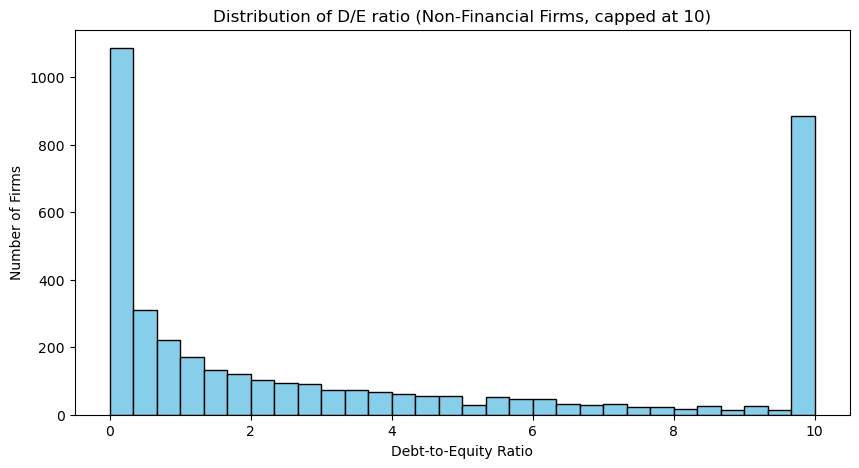

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(non_financials['de_ratio_capped'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of D/E ratio (Non-Financial Firms, capped at 10)")
plt.xlabel("Debt-to-Equity Ratio")
plt.ylabel("Number of Firms")
plt.show()


In [11]:
# Calculate price change
full_data['price_change_%'] = ((full_data['Current Price'] - full_data['t_1_price']) / full_data['t_1_price']) * 100

# Sort dataset to show top gainers and losers
highestmovers = full_data[['Name', 'Industry', 'Current Price', 't_1_price', 'price_change_%']].sort_values('price_change_%', ascending=False)

print("\n📈 Top 5 Gainers by Price %:")
print(highestmovers.head(5))

lowestmovers = full_data[['Name', 'Industry', 'Current Price', 't_1_price', 'price_change_%']].sort_values('price_change_%', ascending=True)
print("\n📉 Top 5 Losers by Price %:")
print(lowestmovers.head(5))



📈 Top 5 Gainers by Price %:
                  Name               Industry  Current Price  t_1_price  \
2880         OTCO Intl          Miscellaneous           8.49       6.46   
700    Caprihans India      Plastics Products         152.45     119.50   
3418  S R G Securities  Finance & Investments          34.80      27.32   
3631  Shanti Guru Inds                Trading          18.46      14.61   
4444  Ventura Textiles  Textiles - Processing          15.04      11.96   

      price_change_%  
2880       31.424149  
700        27.573222  
3418       27.379209  
3631       26.351814  
4444       25.752508  

📉 Top 5 Losers by Price %:
                  Name                                   Industry  \
1691              ICDS                              Miscellaneous   
4113   Tata Inv.Corpn.                      Finance & Investments   
3110  Prit Nandy Comm.  Entertainment / Electronic Media Software   
1552       Hampton Sky                      Finance & Investments   
2174     

In [12]:
# Sort data and show highest ROCE
top_roce = full_data.sort_values('Return on capital employed', ascending = False).head(10)
print("\n🏅 Highest ROCE")
print(top_roce[['Name', 'Industry', 'Return on capital employed', 'Current Price']])


🏅 Highest ROCE
                  Name                   Industry  Return on capital employed  \
1566         Harshdeep              Miscellaneous                    18600.00   
1256    Flora Textiles      Textiles - Processing                     4570.37   
1901   Jagjanani Text.  Textiles - Cotton/Blended                     2400.00   
4444  Ventura Textiles      Textiles - Processing                      940.00   
2404    Manbro Indust.                    Trading                      700.00   
4414  Varyaa Creations                    Trading                      684.75   
94     Addictive Learn              Miscellaneous                      440.99   
2581    Monotype India      Finance & Investments                      437.75   
3873  Sr. Jayala. Auto  Textiles - Cotton/Blended                      313.17   
587      Bhudevi Infra               Construction                      245.54   

      Current Price  
1566          62.00  
1256          24.42  
1901          12.32  
4444

In [13]:
# Cap ROCE at 100% for visualization / analysis
full_data['ROCE_capped'] = full_data['Return on capital employed'].clip(upper=100)


In [14]:
# Median price change % by industry
sector_price_change = full_data.groupby('Industry')['price_change_%'].median().sort_values(ascending=False)

print("📊 Median Price Change % by Industry (Top 10)")
print(sector_price_change.head(10))

print("\n📊 Median Price Change % by Industry (Bottom 10)")
print(sector_price_change.tail(10))


📊 Median Price Change % by Industry (Top 10)
Industry
Textiles - Composite          9.577627
Aquaculture                   5.865324
Fertilizers                   5.485941
Leather / Leather Products    4.778140
Paper                         4.755544
Textiles - Cotton/Blended     4.715090
Textiles - Processing         4.660025
Chlor Alkali / Soda Ash       4.425487
Steel - Pig Iron              4.402965
Finance - Housing             4.349641
Name: price_change_%, dtype: float64

📊 Median Price Change % by Industry (Bottom 10)
Industry
Personal Care - Multinational             -5.164916
Engines                                   -5.196628
Pumps                                     -5.673330
Electrodes - Graphites                    -5.695184
Compressors / Drilling Equipment          -5.933521
Diversified - Mega                        -6.684334
Computers - Software - Large              -7.253871
Automobiles - Scooters And 3 - Wheelers   -7.693702
Abrasives And Grinding Wheels             -9.

In [15]:
metrics = [
    'de_ratio',
    'ROCE_capped',
    'Return on equity',
    'price_change_%'
]

correlation_matrix = full_data[metrics].corr()

print("📈 Correlation Matrix:")
print(correlation_matrix)


📈 Correlation Matrix:
                  de_ratio  ROCE_capped  Return on equity  price_change_%
de_ratio          1.000000     0.017000          0.004964       -0.000719
ROCE_capped       0.017000     1.000000          0.221892       -0.215554
Return on equity  0.004964     0.221892          1.000000       -0.067967
price_change_%   -0.000719    -0.215554         -0.067967        1.000000


In [16]:
# Volatility (std dev of price % change) by industry
sector_volatility = full_data.groupby('Industry')['price_change_%'].std().sort_values(ascending=False)

print("⚠️ Price Volatility by Industry (Top 10 most volatile):")
print(sector_volatility.head(10))

print("\nStable sectors (lowest volatility):")
print(sector_volatility.tail(10))


⚠️ Price Volatility by Industry (Top 10 most volatile):
Industry
Air-conditioners                   10.838123
Automobiles - LCVs / HCVs          10.611428
Telecommunications - Equipment      9.610319
Electrodes - Welding Equipment      9.430229
Ceramics - Tiles / Sanitaryware     9.048886
Shipping                            8.722211
Computers - Hardware                8.713261
Breweries & Distilleries            8.634082
Textiles - Composite                8.579839
Miscellaneous                       8.080861
Name: price_change_%, dtype: float64

Stable sectors (lowest volatility):
Industry
Abrasives And Grinding Wheels                 3.221037
Computers - Software - Large                  2.950087
Dry Cells                                     2.841736
Automobiles - Tractors                        2.790602
Food - Processing - MNC                       2.216265
Transport - Airlines                          1.466837
Moulded Luggage                               0.659723
Couriers         

In [17]:
def classify_firm(row):
    if row['ROCE_capped'] > 15 and row['de_ratio'] < 2:
        return 'Healthy High Performer'
    elif row['ROCE_capped'] > 15 and row['de_ratio'] >= 2:
        return 'High Risk Speculator'
    elif row['ROCE_capped'] <= 15 and row['de_ratio'] >= 2:
        return 'High Risk Low Return'
    else:
        return 'Low Risk Moderate Return'

full_data['Performance_Category'] = full_data.apply(classify_firm, axis=1)

# Check category counts
print("\n🏷️ Firm Classification by ROCE & D/E:")
print(full_data['Performance_Category'].value_counts())



🏷️ Firm Classification by ROCE & D/E:
Performance_Category
Low Risk Moderate Return    1770
High Risk Low Return        1410
Healthy High Performer       765
High Risk Speculator         723
Name: count, dtype: int64


In [18]:
industry_roce = full_data.groupby('Industry')['ROCE_capped'].median().sort_values(ascending=False)

print("\n📊 Median ROCE by Industry (Top 10)")
print(industry_roce.head(10))

print("\n📊 Median ROCE by Industry (Bottom 10)")
print(industry_roce.tail(10))



📊 Median ROCE by Industry (Top 10)
Industry
Personal Care - Multinational                 74.40
Food - Processing - MNC                       48.92
Pharmaceuticals - Multinational               45.75
Pesticides / Agrochemicals - Multinational    33.83
Computers - Software - Large                  29.84
Cigarettes                                    27.54
Electronics - Consumer                        26.60
Engines                                       25.66
Pumps                                         24.43
Electrodes - Welding Equipment                23.16
Name: ROCE_capped, dtype: float64

📊 Median ROCE by Industry (Bottom 10)
Industry
Computers - Software - Converts              3.385
Entertainment / Electronic Media Software    3.320
Textiles - Cotton/Blended                    3.275
Textiles - Manmade                           2.350
Textiles - Composite                         2.285
Tea                                          2.220
Cement - South India                         1.

In [19]:
growth_value_clean = full_data[
    (full_data['EPS growth 3Years'] > 5) &       # meaningful growth
    (full_data['EPS growth 3Years'] < 100) &     # remove absurd spikes
    (full_data['PEG Ratio'] > 0) &
    (full_data['PEG Ratio'] < 1) &
    (~full_data['Industry'].str.contains('Bank|Finance', na=False))
].sort_values('EPS growth 3Years', ascending=False)

growth_value_clean.head(10)


,Name,BSE Code,NSE Code,Industry,Current Price,Debt,Equity capital,Preference capital,Reserves,Secured loan,...,PB X PE,NCAVPS,Market Capt to Cash Flow,Altman Z Score,Market cap to quarterly profit,de_ratio,de_ratio_capped,price_change_%,ROCE_capped,Performance_Category
3280,Raymond,500330.0,RAYMOND,Textiles - Products,3046.20,4181.06,66.55,0.00,4550.79,1579.02,...,52.79,457.40,37.93,4.54,85.30,62.825845,10.000000,5.121852,30.93,High Risk Speculator
2640,N G Industries,530897.0,__NA__,Healthcare,172.00,1.18,3.35,0.00,32.79,0.59,...,18.35,7.03,-56.49,4.56,29.70,0.352239,0.352239,4.451327,17.76,Healthy High Performer
1988,JP Power Ven.,532627.0,JPPOWER,Power Generation And Supply,19.90,4246.04,6853.46,25.59,4614.17,4718.90,...,11.71,3.04,7.08,3.14,15.31,0.619547,0.619547,-2.926829,13.96,Low Risk Moderate Return
1998,Jubilant Inds.,533320.0,JUBLINDS,Chemicals,1653.10,162.02,15.07,0.00,219.20,167.25,...,502.17,153.62,32.93,8.29,218.06,10.751161,10.000000,-4.481527,23.75,High Risk Speculator
2756,Nila Spaces,542231.0,NILASPACES,Construction,9.80,1.08,39.39,0.00,88.19,0.00,...,86.89,2.11,13.44,4.59,177.07,0.027418,0.027418,-2.487562,17.09,Healthy High Performer
872,Crane Infra,538770.0,__NA__,Construction,30.97,0.01,7.24,0.00,22.43,0.00,...,11.76,0.17,-11.61,2.89,65.91,0.001381,0.001381,6.756291,6.44,Low Risk Moderate Return
2526,Milestone Global,531338.0,__NA__,Miscellaneous,33.20,0.00,5.02,0.00,4.25,0.00,...,40.85,12.76,-49.00,6.27,-66.64,0.000000,0.000000,15.197779,10.89,Low Risk Moderate Return
73,Ace Soft. Exp.,531525.0,__NA__,Computers - Software - Medium / Small,243.75,1.90,6.40,0.00,23.68,0.00,...,163.54,18.63,-46.99,8.84,109.86,0.296875,0.296875,-4.613759,21.01,Healthy High Performer
1784,Indo Tech.Trans.,532717.0,INDOTECH,Electric Equipment,1683.20,5.00,10.62,0.00,206.54,11.34,...,313.89,155.29,56.27,10.64,69.91,0.470810,0.470810,-8.533172,30.16,Healthy High Performer
2461,Max Healthcare,543220.0,MAXHEALTH,Healthcare,945.45,1298.95,971.91,0.00,7436.23,564.32,...,946.45,5.84,81.86,14.13,365.10,1.336492,1.336492,-1.988327,16.01,Healthy High Performer


In [20]:
growth_value_quality = growth_value_clean[
    (growth_value_clean['ROCE_capped'] > 15) &
    (growth_value_clean['de_ratio'] < 1)
]

growth_value_quality[['Name', 'Industry',
                      'EPS growth 3Years',
                      'PEG Ratio',
                      'ROCE_capped',
                      'de_ratio',
                      'Current Price']].head(10)


,Name,Industry,EPS growth 3Years,PEG Ratio,ROCE_capped,de_ratio,Current Price
2640,N G Industries,Healthcare,98.82,0.40,17.76,0.352239,172.00
2756,Nila Spaces,Construction,96.94,0.80,17.09,0.027418,9.80
73,Ace Soft. Exp.,Computers - Software - Medium / Small,95.51,0.60,21.01,0.296875,243.75
1784,Indo Tech.Trans.,Electric Equipment,95.31,0.76,30.16,0.470810,1683.20
4123,Taylormade Renew,Electric Equipment,92.52,0.87,67.14,0.717923,452.10
449,B C C Fuba India,Electronics - Components,90.96,0.34,15.92,0.581319,65.70
3917,Steelcast,Castings & Forgings,85.76,0.70,40.10,0.007905,650.75
4289,U P Hotels,Hotels,82.10,0.75,31.09,0.068519,1645.00
2013,Jyoti Resins,Chemicals,81.91,0.26,65.87,0.000000,1426.10
355,Ashish Polyplast,Plastics Products,81.71,0.73,15.95,0.023529,73.77


In [21]:
# 🟨 Step 1.3: Industry distribution
industry_counts = full_data['Industry'].value_counts().reset_index()
industry_counts.columns = ['Industry', 'Company Count']
print("\n🏭 Top 10 Industries by Company Count:")
print(industry_counts.head(10))


🏭 Top 10 Industries by Company Count:
                                Industry  Company Count
0                  Finance & Investments            560
1                                Trading            532
2                          Miscellaneous            410
3                           Construction            323
4  Computers - Software - Medium / Small            241
5                              Chemicals            139
6                            Engineering            125
7                    Textiles - Products            118
8                       Auto Ancillaries            110
9                 Steel - Medium / Small            104


In [22]:
industry_returns = (
    full_data
    .groupby('Industry')['price_change_%']
    .median()
    .sort_values(ascending=False)
)

industry_returns.head(10)


Industry
Textiles - Composite          9.577627
Aquaculture                   5.865324
Fertilizers                   5.485941
Leather / Leather Products    4.778140
Paper                         4.755544
Textiles - Cotton/Blended     4.715090
Textiles - Processing         4.660025
Chlor Alkali / Soda Ash       4.425487
Steel - Pig Iron              4.402965
Finance - Housing             4.349641
Name: price_change_%, dtype: float64

In [23]:
industry_volatility = (
    full_data
    .groupby('Industry')['price_change_%']
    .std()
    .sort_values(ascending=False)
)

industry_volatility.head(10)


Industry
Air-conditioners                   10.838123
Automobiles - LCVs / HCVs          10.611428
Telecommunications - Equipment      9.610319
Electrodes - Welding Equipment      9.430229
Ceramics - Tiles / Sanitaryware     9.048886
Shipping                            8.722211
Computers - Hardware                8.713261
Breweries & Distilleries            8.634082
Textiles - Composite                8.579839
Miscellaneous                       8.080861
Name: price_change_%, dtype: float64

In [24]:
industry_risk_return = pd.DataFrame({
    'Median Return %': industry_returns,
    'Volatility': industry_volatility
}).dropna()

industry_risk_return.sort_values('Median Return %', ascending=False).head(10)


,Median Return %,Volatility
Industry,,
Textiles - Composite,9.577627,8.579839
Aquaculture,5.865324,7.163758
Fertilizers,5.485941,6.346830
Leather / Leather Products,4.778140,7.780569
Paper,4.755544,6.402967
Textiles - Cotton/Blended,4.715090,6.552752
Textiles - Processing,4.660025,6.765826
Chlor Alkali / Soda Ash,4.425487,6.292928
Steel - Pig Iron,4.402965,5.420511


In [25]:
# Zero-debt companies
zero_debt = full_data[full_data['Debt'] == 0]

print("\n🏦 Zero-Debt Companies:")
print(zero_debt[['Name', 'Industry', 'Current Price', 'Return on capital employed']].head(20))

print(f"\nTotal zero-debt companies: {len(zero_debt)}")



🏦 Zero-Debt Companies:
                 Name                               Industry  Current Price  \
7       3P Land Hold.                  Finance & Investments          38.18   
24   AAA Technologies  Computers - Software - Medium / Small         110.90   
44   Aayush Food&Herb                                Trading         299.00   
51     ABC Gas (Int.)                                Trading          91.58   
58       Abirami Fin.                  Finance & Investments          58.20   
59      ABM Knowledge  Computers - Software - Medium / Small         148.00   
67     Accord Synergy  Telecommunications - Service Provider          28.30   
69   ACE EduTremd Ltd                          Miscellaneous           3.20   
70       Ace Engitech  Computers - Software - Medium / Small          21.56   
72            Ace Men                                Trading          46.00   
74   Achyut Healthcar                                Trading          56.70   
75        ACI Infocom  Compu

In [26]:
# =========================================================
# ZERO-DEBT + QUALITY + PERFORMANCE ANALYSIS (FULL PIPELINE)
# =========================================================

import pandas as pd

# -----------------------------
# 1️⃣ Identify zero-debt companies
# -----------------------------
zero_debt = full_data[full_data['Debt'] == 0].copy()

print(f"Total zero-debt companies: {len(zero_debt)}")

# -----------------------------
# 2️⃣ Remove junk / non-operating firms
# - Minimum ROCE
# - Minimum share price
# -----------------------------
zero_debt_clean = zero_debt[
    (zero_debt['Return on capital employed'] > 5) &
    (zero_debt['Current Price'] > 10)
].copy()

print(f"After basic quality filters: {len(zero_debt_clean)}")

# -----------------------------
# 3️⃣ Cap extreme ROCE values
# (avoids denominator distortions)
# -----------------------------
zero_debt_clean['ROCE_capped'] = (
    zero_debt_clean['Return on capital employed']
    .clip(lower=0, upper=60)
)

# -----------------------------
# 4️⃣ Add market validation
# Keep only companies with positive price performance
# -----------------------------
zero_debt_perf = zero_debt_clean[
    zero_debt_clean['price_change_%'] > 0
].copy()

print(f"After performance filter: {len(zero_debt_perf)}")

# -----------------------------
# 5️⃣ Remove structural zero-debt sectors
# (finance & trading distort analysis)
# -----------------------------
exclude_industries = ['Finance & Investments', 'Trading']

zero_debt_operating = zero_debt_perf[
    ~zero_debt_perf['Industry'].isin(exclude_industries)
].copy()

print(f"After industry filter: {len(zero_debt_operating)}")

# -----------------------------
# 6️⃣ Final ranking:
# High ROCE + strong price performance
# -----------------------------
final_zero_debt = (
    zero_debt_operating
    .sort_values(
        ['ROCE_capped', 'price_change_%'],
        ascending=False
    )
    .head(15)
)

# -----------------------------
# 7️⃣ Display final shortlist
# -----------------------------
print("\n🏆 High-Quality Zero-Debt Companies (Final Shortlist):")
final_zero_debt[
    ['Name', 'Industry', 'ROCE_capped', 'price_change_%', 'Current Price']
]


Total zero-debt companies: 643
After basic quality filters: 267
After performance filter: 87
After industry filter: 45

🏆 High-Quality Zero-Debt Companies (Final Shortlist):


,Name,Industry,ROCE_capped,price_change_%,Current Price
3873,Sr. Jayala. Auto,Textiles - Cotton/Blended,60.00,7.395833,10.31
4038,Swadeshi Polytex,Construction,60.00,6.907895,139.75
3233,Rajvi Logitrade,Miscellaneous,60.00,6.208843,11.29
4636,Yuranus Infrast.,Construction,60.00,2.518566,127.00
1116,Elantas Beck,Chemicals,27.67,3.914107,11697.85
2264,Le Lavoir,Miscellaneous,25.29,2.234425,269.95
3112,Priti Internati.,Miscellaneous,23.93,0.220593,140.84
997,Dhatre Udyog,Steel - Medium / Small,23.46,1.873536,17.40
2078,Kaushalya Infra.,Hotels,23.36,13.331712,745.70
2670,Narmada Gelatine,Chemicals,22.23,4.372279,386.00



⚠️ Companies with negative equity: 0


C:\Users\isada\AppData\Local\Temp\ipykernel_21216\1774590919.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_data['de_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)


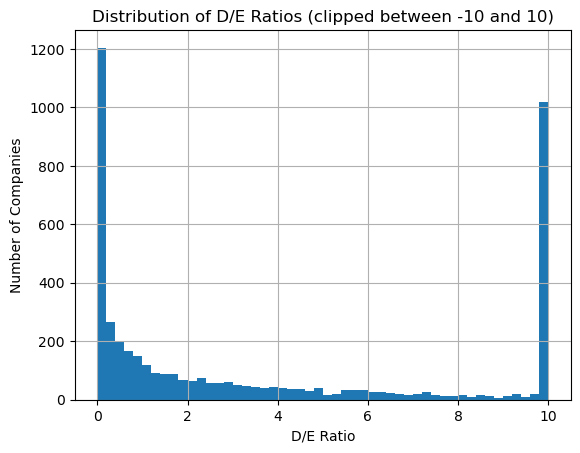

In [27]:
import matplotlib.pyplot as plt

# Companies with negative equity
negative_equity = full_data[full_data['Equity capital'] < 0]
print(f"\n⚠️ Companies with negative equity: {len(negative_equity)}")

# Histogram of D/E ratios
full_data['de_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
full_data['de_ratio'].dropna().clip(-10, 10).hist(bins=50)
plt.title("Distribution of D/E Ratios (clipped between -10 and 10)")
plt.xlabel("D/E Ratio")
plt.ylabel("Number of Companies")
plt.show()


In [28]:
# Negative working capital
neg_wc = full_data[full_data['Working capital'] < 0].sort_values('Working capital', ascending=True).head(10)
print("\n⚠️ Companies with Negative Working Capital:")
print(neg_wc[['Name', 'Working capital', 'Current Price']].head(20))

# Strongest positive working capital
pos_wc = full_data[full_data['Working capital'] > 0].sort_values('Working capital', ascending=False).head(10)
print("\n💪 Companies with Strongest Positive Working Capital:")
print(pos_wc[['Name', 'Working capital', 'Current Price']])



⚠️ Companies with Negative Working Capital:
                  Name  Working capital  Current Price
470      Bajaj Finserv       -108607.39        1584.85
1372  General Insuranc        -51228.90         386.55
103   Aditya Birla Cap        -49959.70         239.90
578      Bharti Airtel        -49689.10        1459.10
2733  New India Assura        -37747.44         243.80
1694     ICICI Lombard        -36915.67        1817.75
3306  Reliance Communi        -28405.00           1.94
4535     Vodafone Idea        -24693.00          17.81
1944       Jet Airways        -15765.69          42.50
1716   IL&FS Transport        -15508.35           6.68

💪 Companies with Strongest Positive Working Capital:
                  Name  Working capital  Current Price
3893    St Bk of India        475932.03         844.25
1687           I R F C        444764.84         172.45
1588         HDFC Bank        240255.06        1696.35
3308  Reliance Industr        178748.00        3126.00
3143  Punjab Natl.Ban

In [29]:
import numpy as np

# ==============================
# 1️⃣ Exclude financial firms
# ==============================
non_financial = full_data[
    ~full_data['Industry'].str.contains(
        'Finance|Bank|Insurance', case=False, na=False
    )
]

print(f"Total non-financial companies: {len(non_financial)}")

# ==============================
# 2️⃣ True Working Capital Risk
# ==============================
wc_risk = (
    non_financial[non_financial['Working capital'] < 0]
    .sort_values('Working capital')
    .head(10)
)

print("\n⚠️ True Working Capital Risk (Non-Financial Firms):")
print(wc_risk[['Name', 'Industry', 'Working capital', 'Current Price']])

# ==============================
# 3️⃣ WC + ROCE Stress Filter
#    (Liquidity + Profitability)
# ==============================
wc_trouble = non_financial[
    (non_financial['Working capital'] < 0) &
    (non_financial['ROCE_capped'] < 10)
].sort_values('Working capital')

print("\n🚨 Liquidity + Profitability Stress Firms:")
print(
    wc_trouble[['Name', 'Industry', 'Working capital', 'ROCE_capped', 'Current Price']]
    .head(15)
)

print(f"\nTotal WC + ROCE stressed firms: {len(wc_trouble)}")

# ==============================
# 4️⃣ Liquidity Flag (Label)
# ==============================
full_data['Liquidity_Flag'] = np.where(
    full_data['Working capital'] < 0,
    'Negative WC',
    'Positive WC'
)

# ==============================
# 5️⃣ Summary by Industry
# ==============================
wc_summary = (
    non_financial
    .groupby('Industry')['Working capital']
    .agg(
        companies='count',
        negative_wc=lambda x: (x < 0).sum(),
        median_wc='median'
    )
    .sort_values('negative_wc', ascending=False)
)

print("\n🏭 Working Capital Stress Summary by Industry:")
print(wc_summary.head(10))


Total non-financial companies: 4040

⚠️ True Working Capital Risk (Non-Financial Firms):
                  Name                                   Industry  \
578      Bharti Airtel      Telecommunications - Service Provider   
3306  Reliance Communi      Telecommunications - Service Provider   
4535     Vodafone Idea      Telecommunications - Service Provider   
1944       Jet Airways                       Transport - Airlines   
1716   IL&FS Transport             Engineering - Turnkey Services   
3309   Reliance Infra.             Engineering - Turnkey Services   
46       Aban Offshore             Oil Drilling / Allied Services   
1544           H P C L                                 Refineries   
4000    Supreme Infra.             Engineering - Turnkey Services   
1027     Dish TV India  Entertainment / Electronic Media Software   

      Working capital  Current Price  
578         -49689.10        1459.10  
3306        -28405.00           1.94  
4535        -24693.00          17.

In [30]:
# Compute correlation matrix for numeric columns
numeric_cols = full_data.select_dtypes(include=['float64','int64'])
corr = numeric_cols.corr()

# Unstack into a long format
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]

# Drop duplicate pairs (A,B) and (B,A)
corr_pairs = corr_pairs.drop_duplicates(subset=['Correlation'])

# Filter strong correlations
strong_corr = corr_pairs[(corr_pairs['Correlation'] > 0.5) | (corr_pairs['Correlation'] < -0.5)]

# Sort by absolute correlation strength
strong_corr = strong_corr.reindex(strong_corr['Correlation'].abs().sort_values(ascending=False).index)

print("📊 Strong correlations (>|0.5|):")
print(strong_corr.head(30))  # show top 30


📊 Strong correlations (>|0.5|):
                        Variable 1                  Variable 2  Correlation
2972           Balance sheet total                Total Assets     1.000000
67722           Interest last year                    Interest     1.000000
9675              Cash Equivalents       Cash end of last year     0.999999
121370              Price to Sales         Market Cap to Sales     0.999999
132464          Price to Cash Flow    Market Capt to Cash Flow     0.999999
63276                        Sales             Sales last year     0.999996
22202                      DMA 200        DMA 200 previous day     0.999995
65876   Operating profit last year            Operating profit     0.999994
66253       Other income last year                Other income     0.999993
67356               EBIT last year                        EBIT     0.999993
66985       Depreciation last year                Depreciation     0.999992
68466                Tax last year                      

In [31]:
# ==============================
# Focused Financial Correlation Analysis
# ==============================

key_metrics = [
    'price_change_%',
    'ROCE_capped',
    'de_ratio_capped',
    'Return on equity',
    'Return on assets',
    'PEG Ratio',
    'Price to Earning',
    'EPS growth 3Years',
    'Sales growth 3Years',
    'Net_Profit_Margin',
    'Operating profit',
    'Working capital',
    'Interest Coverage Ratio',
    'Dividend yield'
]

# Keep only existing columns
key_metrics = [c for c in key_metrics if c in full_data.columns]

# Drop rows with missing values
corr_data = full_data[key_metrics].dropna()

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Extract strong correlations (excluding self)
corr_pairs = (
    corr_matrix
    .where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ['Metric 1', 'Metric 2', 'Correlation']

# Filter meaningful correlations
strong_corr = corr_pairs[
    (corr_pairs['Correlation'].abs() >= 0.3)
].sort_values('Correlation', ascending=False)

print("📊 Meaningful Financial Correlations:")
print(strong_corr.head(20))


📊 Meaningful Financial Correlations:
                Metric 1             Metric 2  Correlation
15           ROCE_capped     Return on assets     0.858487
49      Return on assets          ROCE_capped     0.858487
117     Operating profit      Working capital     0.677083
129      Working capital     Operating profit     0.677083
14           ROCE_capped     Return on equity     0.583891
37      Return on equity          ROCE_capped     0.583891
39      Return on equity     Return on assets     0.522674
51      Return on assets     Return on equity     0.522674
91     EPS growth 3Years  Sales growth 3Years     0.301823
103  Sales growth 3Years    EPS growth 3Years     0.301823
0         price_change_%          ROCE_capped    -0.304488
12           ROCE_capped       price_change_%    -0.304488
3         price_change_%     Return on assets    -0.325790
48      Return on assets       price_change_%    -0.325790


In [32]:
# Pick a few relevant financial health indicators
corr_vars = [
    'Return on capital employed',
    'Return on equity',
    'Profit after tax',
    'Current ratio',
    'Interest Coverage Ratio',
    'Market Capitalization'
]

corr_df = full_data[['de_ratio'] + corr_vars].copy()
corr_df = corr_df.replace([np.inf, -np.inf], np.nan).dropna()

correlations = corr_df.corr()['de_ratio'].sort_values(ascending=False)
print("\n🔗 Correlation of D/E Ratio with Key Metrics:")
print(correlations)



🔗 Correlation of D/E Ratio with Key Metrics:
de_ratio                      1.000000
Profit after tax              0.374882
Market Capitalization         0.271459
Return on equity              0.004169
Return on capital employed   -0.001256
Interest Coverage Ratio      -0.010733
Current ratio                -0.015995
Name: de_ratio, dtype: float64


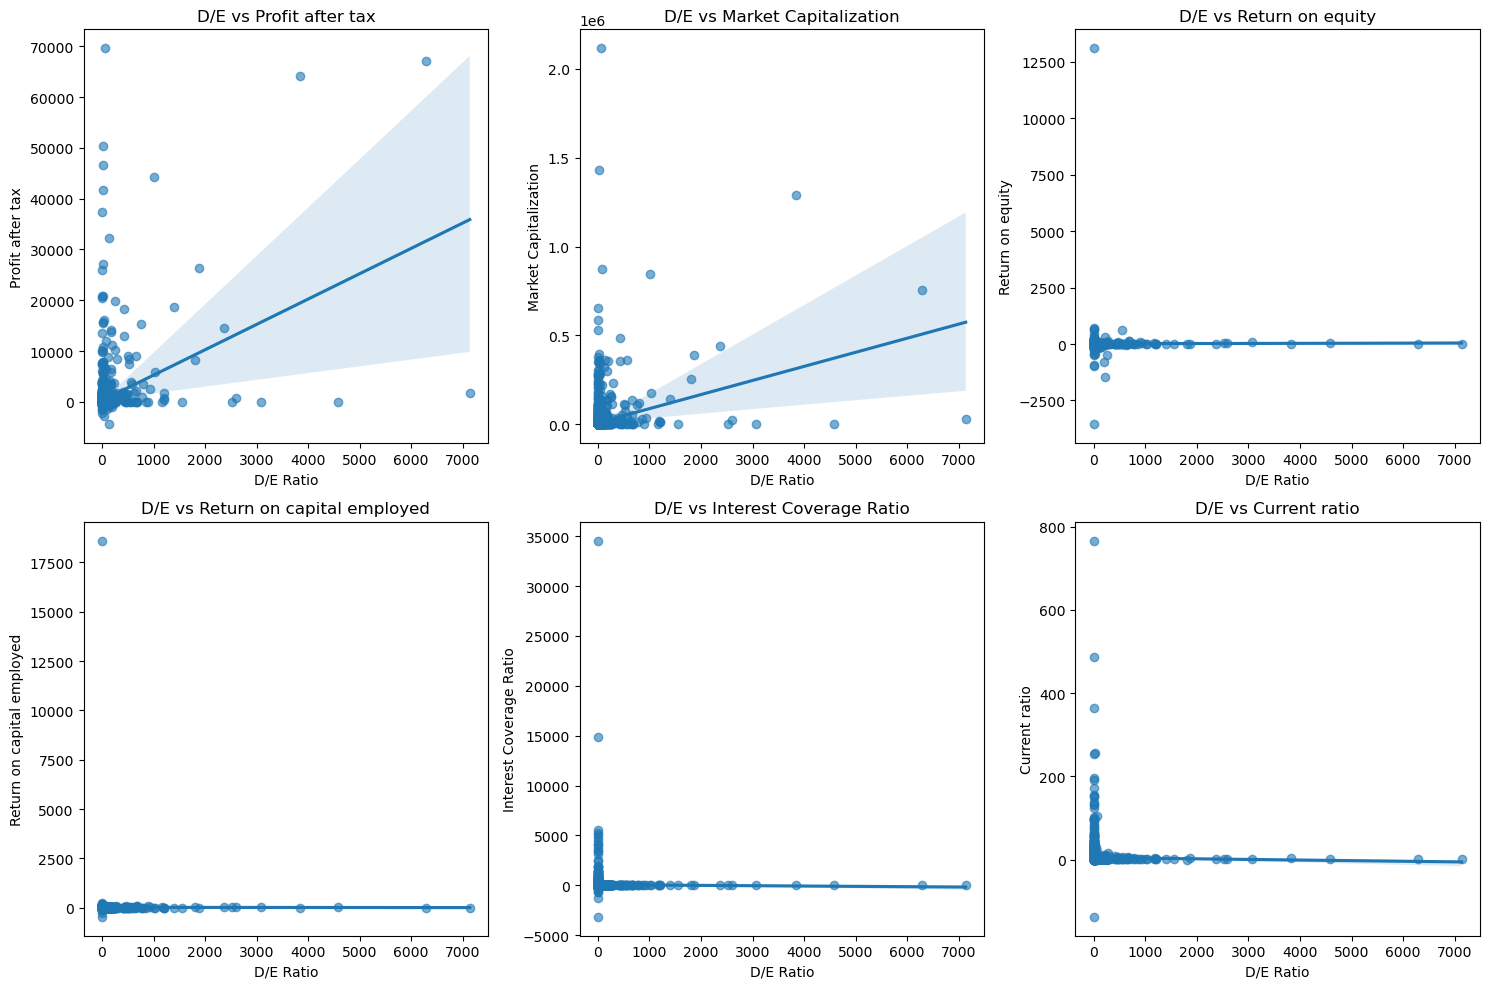


🔗 Spearman Correlation of D/E Ratio with Key Metrics:
Profit after tax: 0.297
Market Capitalization: 0.404
Return on equity: 0.093
Return on capital employed: 0.046
Interest Coverage Ratio: -0.317
Current ratio: -0.407

🔗 Industry-wise Correlations with D/E Ratio:
{'Abrasives And Grinding Wheels': {'Current ratio': -0.21197855765772566,
                                   'Interest Coverage Ratio': -0.9923184488082528,
                                   'Market Capitalization': 0.6658549298245512,
                                   'Profit after tax': 0.7678261166037288,
                                   'Return on capital employed': -0.15806037129121606,
                                   'Return on equity': -0.05420824440078122,
                                   'de_ratio': 1.0},
 'Air-conditioners': {'Current ratio': -0.09532942338593034,
                      'Interest Coverage Ratio': 0.6410423815777813,
                      'Market Capitalization': 0.8526359283396548,
        

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# 1️⃣ Scatter plots with regression lines for key metrics
metrics_to_plot = ['Profit after tax', 'Market Capitalization', 'Return on equity', 
                   'Return on capital employed', 'Interest Coverage Ratio', 'Current ratio']

plt.figure(figsize=(15, 10))

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.regplot(x='de_ratio', y=metric, data=corr_df, scatter_kws={'alpha':0.6})
    plt.xlabel('D/E Ratio')
    plt.ylabel(metric)
    plt.title(f'D/E vs {metric}')

plt.tight_layout()
plt.show()


# 2️⃣ Spearman correlation (non-linear relationships)
spearman_corrs = {}
for metric in metrics_to_plot:
    corr, p_value = spearmanr(corr_df['de_ratio'], corr_df[metric], nan_policy='omit')
    spearman_corrs[metric] = corr

print("\n🔗 Spearman Correlation of D/E Ratio with Key Metrics:")
for metric, corr in spearman_corrs.items():
    print(f"{metric}: {corr:.3f}")


# 3️⃣ Optional: Industry-wise correlations (if 'Industry' column exists)
if 'Industry' in full_data.columns:
    industries = full_data['Industry'].unique()
    industry_corrs = {}
    for ind in industries:
        temp_df = full_data[full_data['Industry'] == ind][['de_ratio'] + metrics_to_plot].replace([np.inf, -np.inf], np.nan).dropna()
        if not temp_df.empty:
            corr = temp_df.corr()['de_ratio']
            industry_corrs[ind] = corr.to_dict()

    # Display industry-wise correlation for D/E ratio
    import pprint
    print("\n🔗 Industry-wise Correlations with D/E Ratio:")
    pprint.pprint(industry_corrs)


In [34]:
import matplotlib.pyplot as plt

# Identify extreme outliers in D/E ratio
q1 = full_data['de_ratio'].quantile(0.25)
q3 = full_data['de_ratio'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

outliers = full_data[(full_data['de_ratio'] < lower_bound) | (full_data['de_ratio'] > upper_bound)]
print(f"\n⚠️ {len(outliers)} extreme D/E outliers detected:")
print(outliers[['Industry', 'de_ratio', 'Profit after tax', 'Market Capitalization']])



⚠️ 658 extreme D/E outliers detected:
                                   Industry     de_ratio  Profit after tax  \
2                     Finance & Investments   263.915575            804.18   
4     Computers - Software - Medium / Small    37.222222              1.14   
21                    Finance & Investments   417.260606             91.71   
25                        Finance - Housing    35.362296            749.64   
43                        Finance - Housing   156.663002            490.69   
...                                     ...          ...               ...   
4622                 Personal Care - Indian  2526.000000              9.02   
4623                              Chemicals    50.792982             57.12   
4628                 Banks - Private Sector    51.319461           1285.20   
4664                            Fertilizers    42.392772             99.81   
4665                                  Sugar    79.832438             -0.71   

      Market Capitalizat

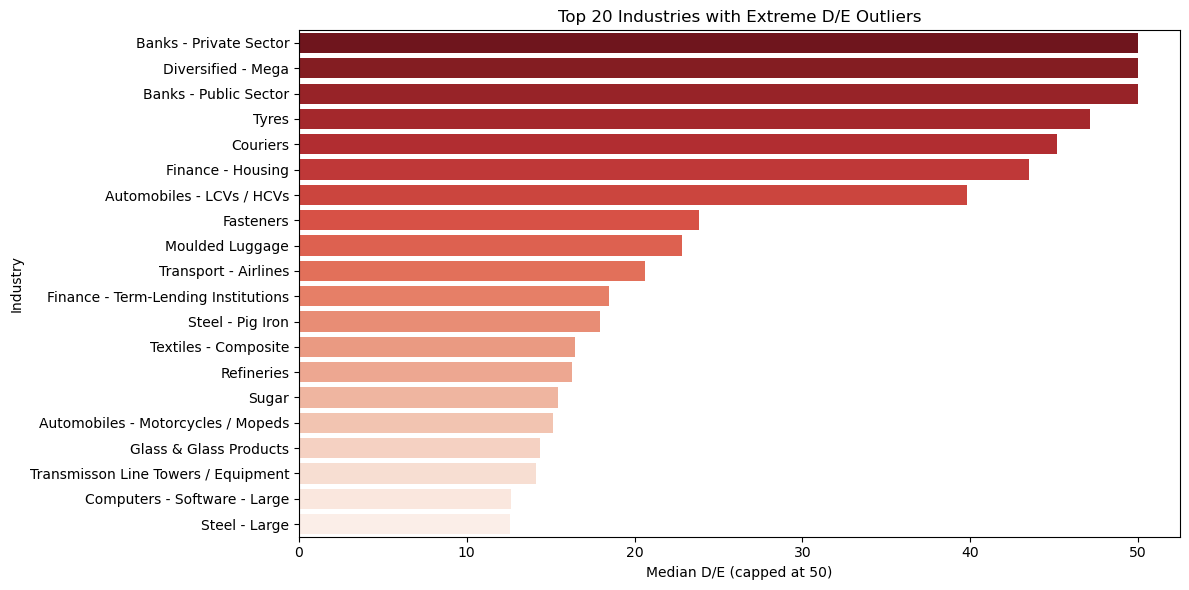

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume your dataframe is called full_data
# Columns: ['Industry', 'de_ratio', 'Profit after tax', 'Market Capitalization']

# 1️⃣ Cap extreme D/E ratios for visualization
full_data['de_ratio_capped'] = full_data['de_ratio'].clip(upper=50)

# 2️⃣ Aggregate by industry: median D/E and count of outliers
industry_summary = full_data.groupby('Industry').agg(
    median_de=('de_ratio_capped', 'median'),
    outlier_count=('de_ratio_capped', 'size')
).reset_index()

# 3️⃣ Sort by median D/E descending
industry_summary = industry_summary.sort_values(by='median_de', ascending=False)

# Optional: focus on top 20 industries with highest median D/E
top_industries = industry_summary.head(20)

# 4️⃣ Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_industries,
    x='median_de',
    y='Industry',
    palette='Reds_r'
)
plt.xlabel('Median D/E (capped at 50)')
plt.ylabel('Industry')
plt.title('Top 20 Industries with Extreme D/E Outliers')
plt.tight_layout()
plt.show()



🏆 Zero-Debt Companies: 643
                Name                               Industry  Equity capital
7      3P Land Hold.                  Finance & Investments            3.60
24  AAA Technologies  Computers - Software - Medium / Small           12.83
44  Aayush Food&Herb                                Trading            3.25
51    ABC Gas (Int.)                                Trading            1.98
58      Abirami Fin.                  Finance & Investments            5.40
59     ABM Knowledge  Computers - Software - Medium / Small           10.24
67    Accord Synergy  Telecommunications - Service Provider            3.47
69  ACE EduTremd Ltd                          Miscellaneous            9.16
70      Ace Engitech  Computers - Software - Medium / Small            3.30
72           Ace Men                                Trading            3.10

⚠️ Companies with Extremely High D/E (>3):
                  Name                    Industry        Debt  \
775    Chola Financial    

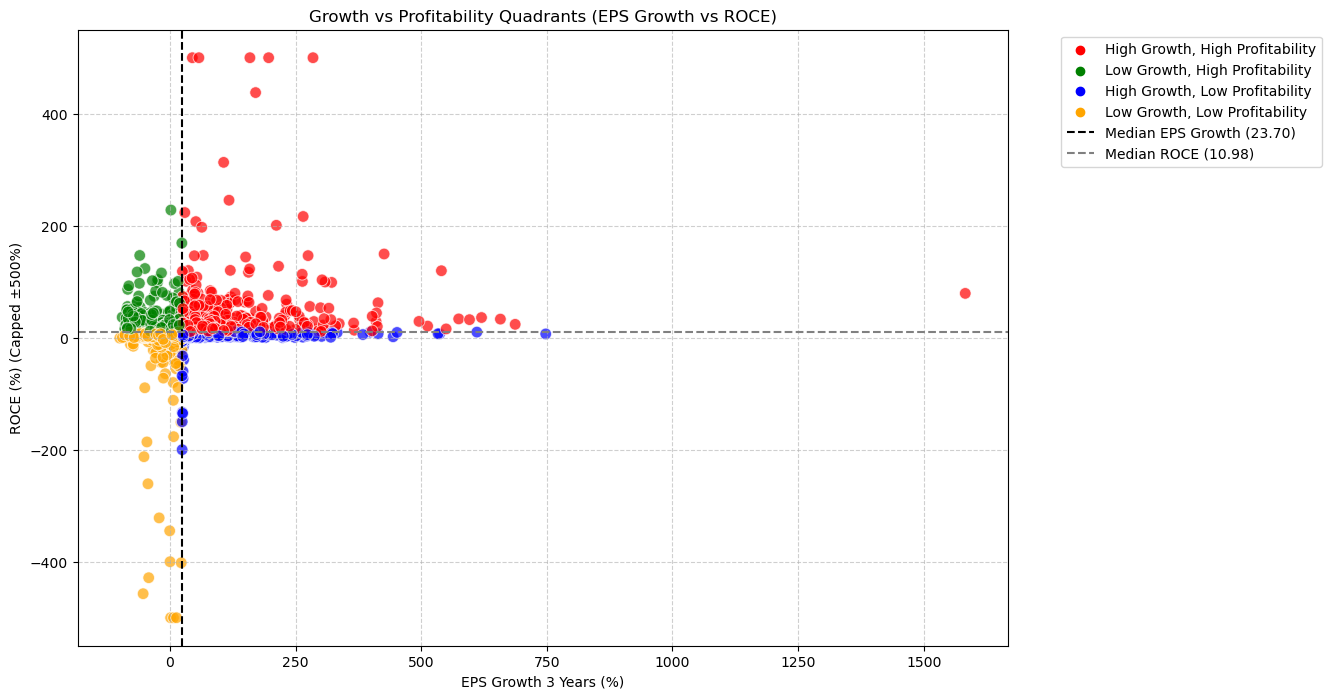

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1️⃣ Ensure numeric columns
# -----------------------------
for col in ['EPS growth 3Years', 'Return on capital employed', 'de_ratio', 'Market Capitalization']:
    full_data[col] = pd.to_numeric(full_data[col], errors='coerce')

# -----------------------------
# 2️⃣ Zero-debt firms
# -----------------------------
zero_debt = full_data[full_data['Debt'] == 0]
print("\n🏆 Zero-Debt Companies:", zero_debt.shape[0])
print(zero_debt[['Name', 'Industry', 'Equity capital']].head(10))

# -----------------------------
# 3️⃣ Extremely high D/E firms
# -----------------------------
high_de_ratio = full_data[full_data['de_ratio'] > 3].sort_values('de_ratio', ascending=False)
print("\n⚠️ Companies with Extremely High D/E (>3):")
print(high_de_ratio[['Name', 'Industry', 'Debt', 'Equity capital', 'de_ratio']].head(10))

# -----------------------------
# 4️⃣ Quadrant classification (EPS vs ROCE)
# -----------------------------
quad_data = full_data[['Name', 'Industry', 'EPS growth 3Years', 
                       'Return on capital employed', 'de_ratio', 'Market Capitalization']].dropna().copy()

# Cap ROCE to avoid extreme dots in the plot
quad_data['ROCE_capped'] = quad_data['Return on capital employed'].clip(-500, 500)

# Compute medians
median_eps = quad_data['EPS growth 3Years'].median()
median_roce = quad_data['ROCE_capped'].median()
print(f"\nMedian EPS Growth (3Y): {median_eps:.2f}")
print(f"Median ROCE (capped): {median_roce:.2f}")

# Quadrant classification
def classify_quadrant(row):
    if row['EPS growth 3Years'] >= median_eps and row['ROCE_capped'] >= median_roce:
        return "High Growth, High Profitability"
    elif row['EPS growth 3Years'] >= median_eps and row['ROCE_capped'] < median_roce:
        return "High Growth, Low Profitability"
    elif row['EPS growth 3Years'] < median_eps and row['ROCE_capped'] >= median_roce:
        return "Low Growth, High Profitability"
    else:
        return "Low Growth, Low Profitability"

quad_data['Quadrant'] = quad_data.apply(classify_quadrant, axis=1)

# -----------------------------
# 5️⃣ High-Quality & Elite Companies
# -----------------------------
quality_bucket = quad_data[quad_data['Quadrant'] == "High Growth, High Profitability"]
elite = quality_bucket[quality_bucket['de_ratio'] <= 1.5]

print("\n✅ High Growth & High Profitability (Quality Bucket):")
print(quality_bucket[['Name', 'Industry', 'EPS growth 3Years', 'ROCE_capped', 'de_ratio']].sort_values(
    by=['EPS growth 3Years', 'ROCE_capped'], ascending=False).head(20))

print("\n🌟 Elite Companies (High Growth + High ROCE + Low D/E ≤ 1.5):")
print(elite[['Name', 'Industry', 'EPS growth 3Years', 'ROCE_capped', 'de_ratio', 'Market Capitalization']].sort_values(
    by=['EPS growth 3Years', 'ROCE_capped'], ascending=False))

print(f"\nTotal Investment-Grade Stocks: {elite.shape[0]}")

# -----------------------------
# 6️⃣ Scatterplot with fixed colors
# -----------------------------
palette = {
    "High Growth, High Profitability": "red",
    "High Growth, Low Profitability": "blue",
    "Low Growth, High Profitability": "green",
    "Low Growth, Low Profitability": "orange"
}

plt.figure(figsize=(12,8))
sns.scatterplot(
    data=quad_data,
    x='EPS growth 3Years',
    y='ROCE_capped',
    hue='Quadrant',
    palette=palette,
    alpha=0.7,
    s=70
)

# Median lines
plt.axvline(median_eps, color='black', linestyle='--', label=f'Median EPS Growth ({median_eps:.2f})')
plt.axhline(median_roce, color='grey', linestyle='--', label=f'Median ROCE ({median_roce:.2f})')

plt.title("Growth vs Profitability Quadrants (EPS Growth vs ROCE)")
plt.xlabel("EPS Growth 3 Years (%)")
plt.ylabel("ROCE (%) (Capped ±500%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [37]:
# List all column names in full_data
print(full_data.columns.tolist())


['Name', 'BSE Code', 'NSE Code', 'Industry', 'Current Price', 'Debt', 'Equity capital', 'Preference capital', 'Reserves', 'Secured loan', 'Unsecured loan', 'Balance sheet total', 'Gross block', 'Revaluation reserve', 'Accumulated depreciation', 'Net block', 'Capital work in progress', 'Investments', 'Current assets', 'Current liabilities', 'Book value of unquoted investments', 'Market value of quoted investments', 'Contingent liabilities', 'Total Assets', 'Working capital', 'Lease liabilities', 'Inventory', 'Trade receivables', 'Face value', 'Cash Equivalents', 'Advance from Customers', 'Trade Payables', 'Number of equity shares preceding year', 'Debt preceding year', 'Working capital preceding year', 'Net block preceding year', 'Gross block preceding year', 'Capital work in progress preceding year', 'Working capital 3Years back', 'Working capital 5Years back', 'Working capital 7Years back', 'Working capital 10Years back', 'Debt 3Years back', 'Debt 5Years back', 'Debt 7Years back', 'De

In [38]:
# ================================
# Robust Operational Efficiency Ranking
# ================================
import numpy as np
import pandas as pd

# ----------------------------
# Helper: find the correct column automatically
def find_col(df, candidates):
    cols = list(df.columns)
    for c in candidates:
        for col in cols:
            if col.strip().lower() == c.strip().lower():
                return col
    for c in candidates:
        for col in cols:
            if c.strip().lower() in col.strip().lower():
                return col
    return None

# ----------------------------
# Detect columns
ebit_col    = find_col(full_data, ['EBIT','Operating profit','EBITDA'])
sales_col   = find_col(full_data, ['Sales'])
assets_col  = find_col(full_data, ['Total Assets'])
debt_col    = find_col(full_data, ['Debt'])
equity_col  = find_col(full_data, ['Equity capital','Net worth','Book value'])
netprofit_col = find_col(full_data, ['Net profit','Profit after tax'])

print("Detected columns:")
print("EBIT:", ebit_col)
print("Sales:", sales_col)
print("Assets:", assets_col)
print("Debt:", debt_col)
print("Equity:", equity_col)
print("Net Profit:", netprofit_col)

# ----------------------------
# Convert to numeric safely
for c in [ebit_col, sales_col, assets_col, debt_col, equity_col, netprofit_col]:
    if c:
        full_data[c] = pd.to_numeric(
            full_data[c].astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('(', '-', regex=False)
            .str.replace(')', '', regex=False),
            errors='coerce'
        )

# ----------------------------
# Base calculations
full_data['EBIT_calc']   = full_data[ebit_col]
full_data['Sales_calc']  = full_data[sales_col]
full_data['Assets_calc'] = full_data[assets_col]
full_data['Debt_calc']   = full_data[debt_col] if debt_col else 0
full_data['Equity_calc'] = full_data[equity_col] if equity_col else np.nan
full_data['Equity_calc'] = full_data['Equity_calc'].replace(0, np.nan)

# ----------------------------
# Metrics
full_data['OPM']  = full_data['EBIT_calc'] / full_data['Sales_calc']        # Operating margin
full_data['ATO']  = full_data['Sales_calc'] / full_data['Assets_calc']      # Asset turnover
full_data['ROCE'] = full_data['EBIT_calc'] / (full_data['Debt_calc'] + full_data['Equity_calc'])

if netprofit_col:
    full_data['ROA'] = full_data[netprofit_col] / full_data['Assets_calc']
else:
    full_data['ROA'] = np.nan

# Clean inf values
for col in ['OPM','ATO','ROCE','ROA']:
    full_data[col] = full_data[col].replace([np.inf, -np.inf], np.nan)

# ----------------------------
# Winsorize at 1st–95th percentile to reduce extreme outliers
for col in ['OPM','ATO']:
    if full_data[col].notna().sum() > 0:
        low, high = full_data[col].quantile([0.01, 0.95])
        full_data[col+'_w'] = full_data[col].clip(lower=low, upper=high)
    else:
        full_data[col+'_w'] = full_data[col]

# Log-transform ROCE (handle negative or zero by shifting)
full_data['ROCE_shifted'] = full_data['ROCE'].copy()
min_roce = full_data['ROCE_shifted'].min()
shift = 1 - min_roce if min_roce <= 0 else 0
full_data['ROCE_shifted'] += shift
full_data['ROCE_log'] = np.log(full_data['ROCE_shifted'])

# ----------------------------
# Industry-relative z-scores
def industry_zscore(df, col):
    def _zscore(s):
        return (s - s.mean()) / (s.std(ddof=0) if s.std(ddof=0) != 0 else 1)
    return df.groupby('Industry')[col].transform(_zscore)

full_data['score_ROCE_log'] = industry_zscore(full_data, 'ROCE_log')
full_data['score_OPM']      = industry_zscore(full_data, 'OPM_w')
full_data['score_ATO']      = industry_zscore(full_data, 'ATO_w')

# Normalize z-scores 0–100
def normalize_0_100(s):
    minv, maxv = s.min(), s.max()
    return 100*(s - minv)/(maxv - minv) if maxv != minv else s*0 + 50

full_data['score_ROCE_log_norm'] = normalize_0_100(full_data['score_ROCE_log'])
full_data['score_OPM_log_norm']  = normalize_0_100(full_data['score_OPM'])
full_data['score_ATO_log_norm']  = normalize_0_100(full_data['score_ATO'])

# ----------------------------
# Composite efficiency score (weights: ROCE 50%, OPM 25%, ATO 25%)
full_data['efficiency_score'] = (
    0.5 * full_data['score_ROCE_log_norm'] +
    0.25 * full_data['score_OPM_log_norm'] +
    0.25 * full_data['score_ATO_log_norm']
)

# ----------------------------
# Top & bottom 20
top20 = full_data.sort_values('efficiency_score', ascending=False).head(20)[
    ['Name','Industry','efficiency_score','ROCE','OPM','ATO',
     'score_ROCE_log_norm','score_OPM_log_norm','score_ATO_log_norm']
]
bottom20 = full_data.sort_values('efficiency_score', ascending=True).head(20)[
    ['Name','Industry','efficiency_score','ROCE','OPM','ATO',
     'score_ROCE_log_norm','score_OPM_log_norm','score_ATO_log_norm']
]

print("\nTop 20 companies by Efficiency Score (log-transformed ROCE):")
print(top20.to_string(index=False))

print("\nBottom 20 companies by Efficiency Score (log-transformed ROCE):")
print(bottom20.to_string(index=False))

# ----------------------------
# Save results
full_data.to_csv("operational_efficiency_scores_log_cleaned.csv", index=False)
print("\nSaved 'operational_efficiency_scores_log_cleaned.csv'")


Detected columns:
EBIT: EBIT
Sales: Sales
Assets: Total Assets
Debt: Debt
Equity: Equity capital
Net Profit: Net profit

Top 20 companies by Efficiency Score (log-transformed ROCE):
            Name                              Industry  efficiency_score        ROCE      OPM       ATO  score_ROCE_log_norm  score_OPM_log_norm  score_ATO_log_norm
     Blue Pebble                         Miscellaneous         73.509761  501.000000 0.227108  2.113027            83.827005           62.099645           64.285391
Elcid Investment                 Finance & Investments         73.227695 1157.950000 0.991268  0.018717           100.000000           63.789806           29.120976
        Delaplex Computers - Software - Medium / Small         65.042016 1175.000000 0.212285  0.835472            78.663623           62.213051           40.627767
           NESCO                          Construction         60.313460   33.242509 0.703397  0.255886            71.587299           64.383263           33.

Top 10 industries by average efficiency:
                                    Industry  avg_efficiency  \
8   Automobiles - Scooters And 3 - Wheelers       40.364626   
15                       Cables - Telephone       39.465963   
32               Detergents / Intermediates       39.433579   
44                   Electronics - Consumer       39.095095   
19                          Cement Products       38.667481   
79                    Printing & Stationery       38.337079   
98                       Textiles - Manmade       38.310386   
56                   Glass & Glass Products       38.296703   
52                        Finance - Housing       38.266619   
71                           Petrochemicals       38.183745   

    median_efficiency  efficiency_std  
8           40.364626        6.244340  
15          38.042519        6.430542  
32          38.023643        6.272560  
44          38.704554        3.858002  
19          39.009738        2.055593  
79          36.312247   

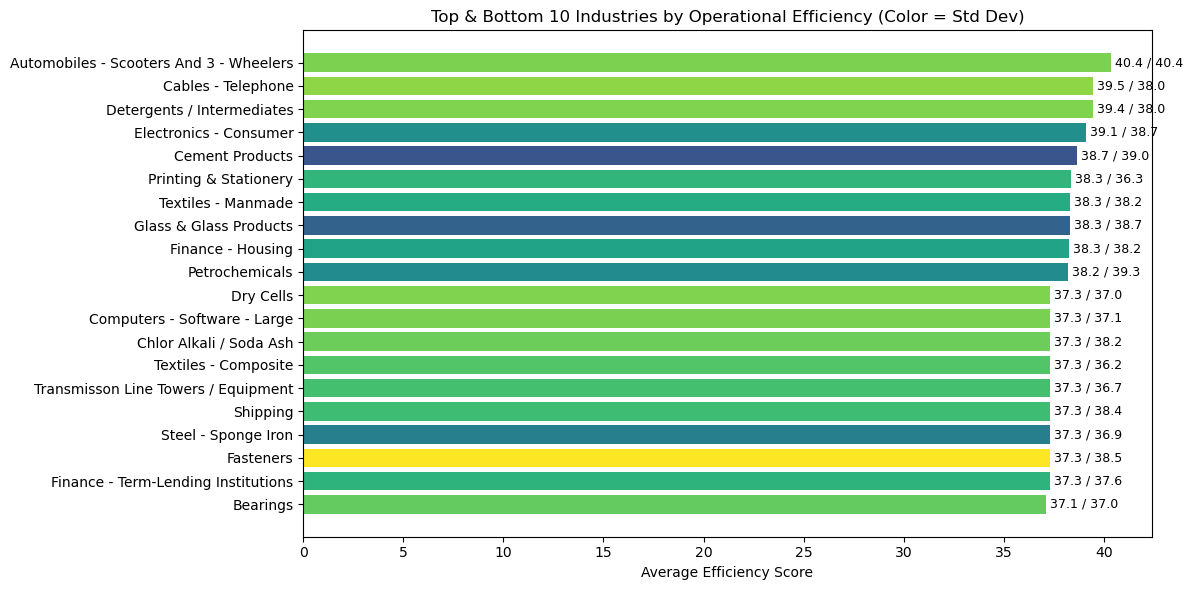

<Figure size 1500x800 with 0 Axes>

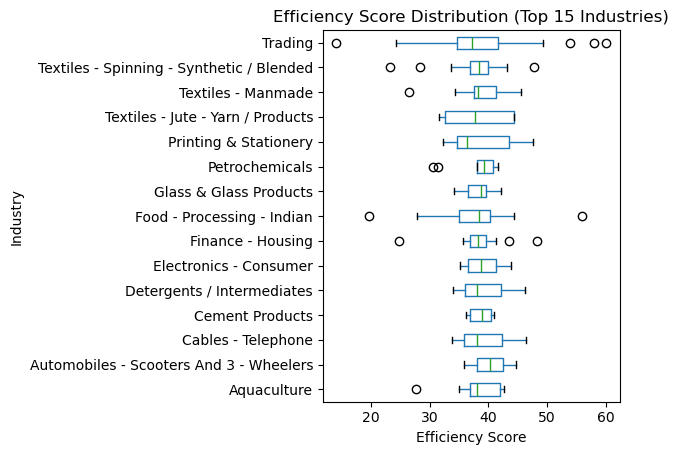

Saved 'industry_efficiency_summary.csv'


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Industry summary: mean, median, std
# ============================
industry_summary = (
    full_data.groupby("Industry")['efficiency_score']
    .agg(['mean', 'median', 'std'])
    .reset_index()
    .rename(columns={'mean':'avg_efficiency', 'median':'median_efficiency', 'std':'efficiency_std'})
)

# Sort by average efficiency
industry_summary = industry_summary.sort_values('avg_efficiency', ascending=False)

# Top 10 and Bottom 10 industries
top10 = industry_summary.head(10)
bottom10 = industry_summary.tail(10)
top_bottom = pd.concat([top10, bottom10])

print("Top 10 industries by average efficiency:\n", top10)
print("\nBottom 10 industries by average efficiency:\n", bottom10)

# ============================
# Bar chart: Top & Bottom 10 (color = variability)
# ============================
colors = plt.cm.viridis(top_bottom['efficiency_std'] / top_bottom['efficiency_std'].max())

plt.figure(figsize=(12, 6))
bars = plt.barh(top_bottom['Industry'], top_bottom['avg_efficiency'], color=colors)
plt.xlabel("Average Efficiency Score")
plt.title("Top & Bottom 10 Industries by Operational Efficiency (Color = Std Dev)")
plt.gca().invert_yaxis()  # Highest on top

# Annotate bars with average and median
for bar, avg, med in zip(bars, top_bottom['avg_efficiency'], top_bottom['median_efficiency']):
    plt.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f"{avg:.1f} / {med:.1f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================
# Boxplot: Efficiency distribution (Top 15 industries)
# ============================
top15_industries = industry_summary.head(15)['Industry'].tolist()
top15_data = full_data[full_data['Industry'].isin(top15_industries)]

plt.figure(figsize=(15, 8))
box = top15_data.boxplot(column='efficiency_score', by='Industry', vert=False, grid=False)
plt.title("Efficiency Score Distribution (Top 15 Industries)")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Efficiency Score")
plt.tight_layout()
plt.show()

# ============================
# Optional: full report table
# ============================
industry_summary_full = (
    full_data.groupby("Industry")[["efficiency_score", "ROCE", "OPM", "ATO"]]
    .agg(['mean', 'median', 'std'])
)
industry_summary_full.columns = ['_'.join(col) for col in industry_summary_full.columns]
industry_summary_full = industry_summary_full.reset_index()
industry_summary_full = industry_summary_full.sort_values('efficiency_score_mean', ascending=False)

# Save to CSV
industry_summary_full.to_csv("industry_efficiency_summary.csv", index=False)
print("Saved 'industry_efficiency_summary.csv'")


REGRESSION ANALYSIS


📊 LINEAR REGRESSION PERFORMANCE
R²   : -0.0850
RMSE : 7.16
MAE  : 5.46

📈 LINEAR REGRESSION COEFFICIENTS
              Feature  Coefficient
                  ATO     0.606544
                  ROA     0.430558
             de_ratio     0.373346
    EPS growth 3Years     0.357395
                  OPM     0.254390
            PEG Ratio    -0.055938
     efficiency_score    -0.681945
Market Capitalization    -0.725486
          ROCE_capped    -1.700652


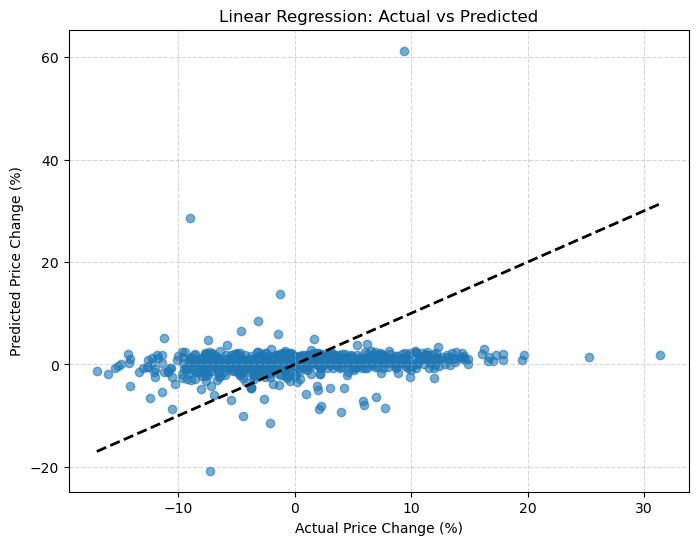

In [40]:
# =====================================
# LINEAR REGRESSION + PDP (STOCKS)
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

# -------------------------------
# 1️⃣ Feature set & target
# -------------------------------
features = [
    'ROCE_capped',
    'OPM',
    'ATO',
    'ROA',
    'de_ratio',
    'EPS growth 3Years',
    'PEG Ratio',
    'Market Capitalization',
    'efficiency_score'
]

target = 'price_change_%'

df = full_data[features + [target]].dropna().copy()

X = df[features]
y = df[target]

# -------------------------------
# 2️⃣ Train / Test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# -------------------------------
# 3️⃣ Scale features
# -------------------------------
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# -------------------------------
# 4️⃣ Linear Regression
# -------------------------------
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test_scaled)

# -------------------------------
# 5️⃣ Performance metrics
# -------------------------------
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("\n📊 LINEAR REGRESSION PERFORMANCE")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# -------------------------------
# 6️⃣ Coefficients
# -------------------------------
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': linreg.coef_
}).sort_values('Coefficient', ascending=False)

print("\n📈 LINEAR REGRESSION COEFFICIENTS")
print(coef_df.to_string(index=False))

# -------------------------------
# 7️⃣ Diagnostic plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--',
    linewidth=2
)
plt.xlabel("Actual Price Change (%)")
plt.ylabel("Predicted Price Change (%)")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


lr_results = {
    "Model": "Linear Regression",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae
}



📊 RIDGE REGRESSION PERFORMANCE
R²   : 0.0199
RMSE : 6.80
MAE  : 5.37
Best α: 568.9866029018293

📈 RIDGE COEFFICIENTS
                 Feature  Coefficient
2                    ATO     0.380989
4               de_ratio     0.257815
5      EPS growth 3Years     0.221153
1                    OPM     0.208581
3                    ROA     0.195767
6              PEG Ratio    -0.048487
8       efficiency_score    -0.549798
7  Market Capitalization    -0.568579
0            ROCE_capped    -1.260896

📊 LASSO REGRESSION PERFORMANCE
R²   : 0.0478
RMSE : 6.70
MAE  : 5.30
Best α: 0.19306977288832497

📈 LASSO COEFFICIENTS (Feature Selection)
                 Feature  Coefficient
2                    ATO     0.201790
5      EPS growth 3Years     0.120865
3                    ROA     0.103494
1                    OPM     0.098019
4               de_ratio     0.089127
6              PEG Ratio    -0.000000
8       efficiency_score    -0.354701
7  Market Capitalization    -0.467372
0            ROCE_ca

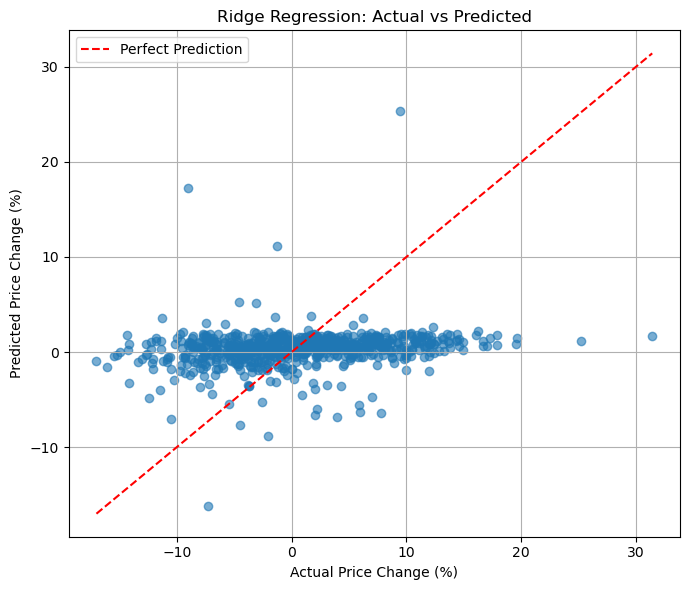

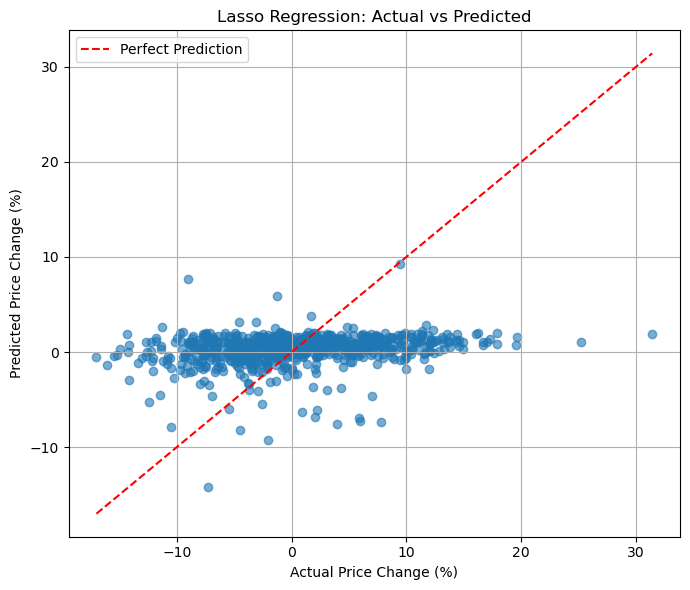

In [41]:
# =====================================
# RIDGE & LASSO REGRESSION + PDP
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

# -------------------------------
# 1️⃣ Feature set & target
# -------------------------------
features = [
    'ROCE_capped',
    'OPM',
    'ATO',
    'ROA',
    'de_ratio',
    'EPS growth 3Years',
    'PEG Ratio',
    'Market Capitalization',
    'efficiency_score'
]

target = 'price_change_%'

df = full_data[features + [target]].dropna().copy()

X = df[features]
y = df[target]

# -------------------------------
# 2️⃣ Train / Test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# -------------------------------
# 3️⃣ RIDGE REGRESSION (L2)
# -------------------------------
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 50)))
])
ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

# Metrics
ridge_r2   = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)

print("\n📊 RIDGE REGRESSION PERFORMANCE")
print(f"R²   : {ridge_r2:.4f}")
print(f"RMSE : {ridge_rmse:.2f}")
print(f"MAE  : {ridge_mae:.2f}")
print(f"Best α: {ridge_pipeline.named_steps['ridge'].alpha_}")

# Ridge coefficients
ridge_coefs = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge_pipeline.named_steps['ridge'].coef_
}).sort_values('Coefficient', ascending=False)

print("\n📈 RIDGE COEFFICIENTS")
print(ridge_coefs)

# -------------------------------
# 4️⃣ LASSO REGRESSION (L1)
# -------------------------------
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(alphas=np.logspace(-3, 1, 50), max_iter=5000))
])
lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

# Metrics
lasso_r2   = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae  = mean_absolute_error(y_test, y_pred_lasso)

print("\n📊 LASSO REGRESSION PERFORMANCE")
print(f"R²   : {lasso_r2:.4f}")
print(f"RMSE : {lasso_rmse:.2f}")
print(f"MAE  : {lasso_mae:.2f}")
print(f"Best α: {lasso_pipeline.named_steps['lasso'].alpha_}")

# Lasso coefficients
lasso_coefs = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso_pipeline.named_steps['lasso'].coef_
}).sort_values('Coefficient', ascending=False)

print("\n📈 LASSO COEFFICIENTS (Feature Selection)")
print(lasso_coefs)

# -------------------------------
# 5️⃣ Actual vs Predicted plots
# -------------------------------
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(7,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], 'r--', label='Perfect Prediction')
    plt.xlabel("Actual Price Change (%)")
    plt.ylabel("Predicted Price Change (%)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_actual_vs_pred(y_test, y_pred_ridge, "Ridge Regression: Actual vs Predicted")
plot_actual_vs_pred(y_test, y_pred_lasso, "Lasso Regression: Actual vs Predicted")



ridge_results = {
    "Model": "Ridge",
    "R2": ridge_r2,
    "RMSE": ridge_rmse,
    "MAE": ridge_mae
}



lasso_results = {
    "Model": "Lasso",
    "R2": lasso_r2,
    "RMSE": lasso_rmse,
    "MAE": lasso_mae
}



📊 ELASTIC NET REGRESSION PERFORMANCE
R²   : 0.0452
RMSE : 6.71
MAE  : 5.31
Best α: 0.19306977288832497
Best l1_ratio: 0.9

📈 ELASTIC NET COEFFICIENTS
              Feature  Coefficient
                  ATO     0.231698
    EPS growth 3Years     0.135293
                  ROA     0.119095
             de_ratio     0.112791
                  OPM     0.111652
            PEG Ratio    -0.000000
     efficiency_score    -0.385160
Market Capitalization    -0.484283
          ROCE_capped    -1.370989


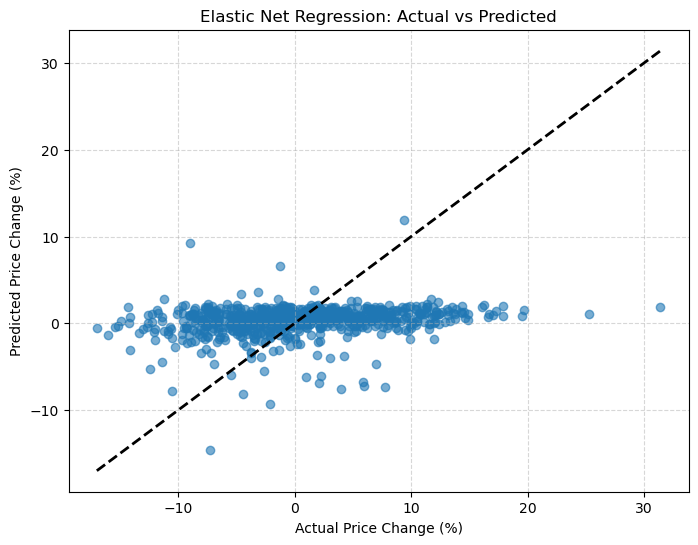

In [42]:
# =====================================
# ELASTIC NET REGRESSION (STOCKS) + PDP (ALL FEATURES)
# =====================================

from sklearn.linear_model import ElasticNetCV
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Feature set & target
# ----------------------------
features = [
    'ROCE_capped',
    'OPM',
    'ATO',
    'ROA',
    'de_ratio',
    'EPS growth 3Years',
    'PEG Ratio',
    'Market Capitalization',
    'efficiency_score'
]

target = 'price_change_%'

model_data = full_data[features + [target]].dropna()

X = model_data[features]
y = model_data[target]

# ----------------------------
# 2️⃣ Train / test split
# ----------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ----------------------------
# 3️⃣ Scale features
# ----------------------------
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ----------------------------
# 4️⃣ Elastic Net CV
# ----------------------------
elastic_net = ElasticNetCV(
    l1_ratio=np.linspace(0.1, 0.9, 9),
    alphas=np.logspace(-3, 1, 50),
    cv=5,
    max_iter=5000,
    random_state=42
)
elastic_net.fit(X_train_scaled, y_train)
y_pred = elastic_net.predict(X_test_scaled)

# ----------------------------
# 5️⃣ Performance metrics
# ----------------------------
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("\n📊 ELASTIC NET REGRESSION PERFORMANCE")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"Best α: {elastic_net.alpha_}")
print(f"Best l1_ratio: {elastic_net.l1_ratio_}")

# ----------------------------
# 6️⃣ Coefficients
# ----------------------------
import pandas as pd
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': elastic_net.coef_
}).sort_values('Coefficient', ascending=False)

print("\n📈 ELASTIC NET COEFFICIENTS")
print(coef_df.to_string(index=False))

# ----------------------------
# 7️⃣ Diagnostic plot
# ----------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
plt.xlabel("Actual Price Change (%)")
plt.ylabel("Predicted Price Change (%)")
plt.title("Elastic Net Regression: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



enet_results = {
    "Model": "Elastic Net",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae
}


Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.6s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   5.9s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   5.9s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   6.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   2.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   2.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   2.4s
[CV] END max_depth=5, min_samples_leaf=

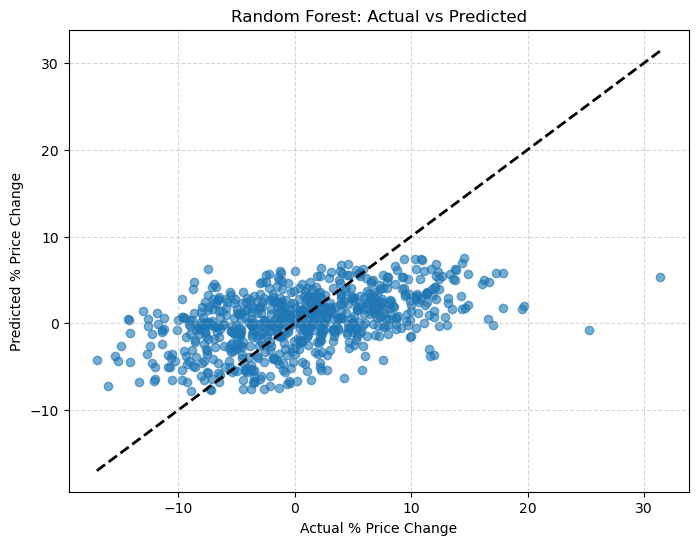

In [43]:
# =====================================================
# RANDOM FOREST REGRESSION – PREDICT STOCK % PRICE CHANGE
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

# -------------------------------
# 1️⃣ Feature set & target
# -------------------------------
features = [
    'ROCE_capped',
    'OPM',
    'ATO',
    'ROA',
    'de_ratio',
    'EPS growth 3Years',
    'PEG Ratio',
    'Market Capitalization',
    'efficiency_score'
]

target = 'price_change_%'

# Drop rows with missing values in selected features/target
df = full_data[features + [target]].dropna().copy()

X = df[features]
y = df[target]

# -------------------------------
# 2️⃣ Train / Test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# -------------------------------
# 3️⃣ Scale features (optional for RF)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# 4️⃣ GridSearch for RF hyperparameters
# -------------------------------
param_grid = {
    'n_estimators': [200, 500],  # keep smaller for faster testing
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=1)  # ⚠ Windows safe

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=1,  # ⚠ Windows safe
    verbose=2
)

# Fit grid search
grid_search_rf.fit(X_train_scaled, y_train)

# Best hyperparameters
best_params = grid_search_rf.best_params_
print("\n✅ Best Random Forest parameters:", best_params)

# -------------------------------
# 5️⃣ Train RF with best parameters
# -------------------------------
best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=1)
best_rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = best_rf.predict(X_test_scaled)

# -------------------------------
# 6️⃣ Performance metrics
# -------------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 RANDOM FOREST PERFORMANCE")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# -------------------------------
# 7️⃣ Feature importance
# -------------------------------
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📈 FEATURE IMPORTANCE")
print(feat_imp.to_string(index=False))

# -------------------------------
# 8️⃣ Actual vs Predicted plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
plt.xlabel("Actual % Price Change")
plt.ylabel("Predicted % Price Change")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# results
rf_results = {
    "Model": "Random Forest",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae
}

# store predictions if needed later
rf_pred = y_pred.copy()



Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, max_iter=500; total time=   1.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, max_iter=500; total time=   1.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=constant, max_iter=500; total time=   1.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, max_iter=500; total time=   1.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, max_iter=500; total time=   1.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(50,), learning_rate=adaptive, max_iter=500; total time=   1.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100,), learning_rate=constant, max_iter=500; total time=   2.2s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100,), learning_r

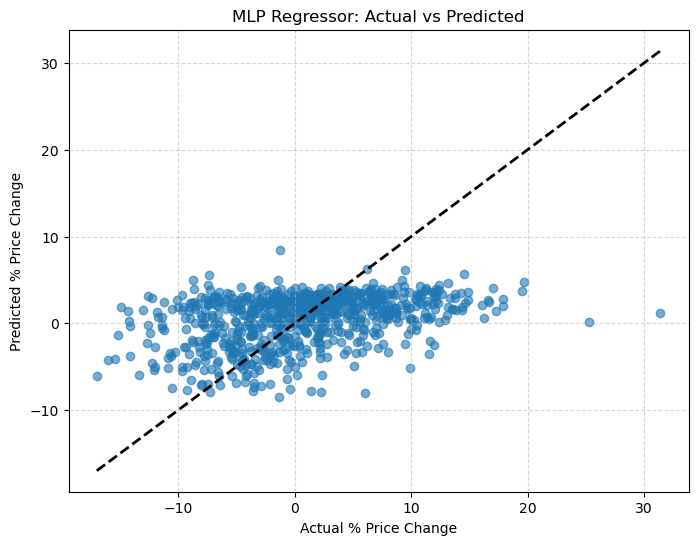

In [44]:
# =====================================================
# MLP REGRESSOR – PREDICT STOCK % PRICE CHANGE
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.exceptions import ConvergenceWarning  # ✅ needed for warning filter

# -------------------------------
# Suppress warnings
# -------------------------------
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# -------------------------------
# 1️⃣ Feature set & target
# -------------------------------
features = [
    'ROCE_capped',
    'OPM',
    'ATO',
    'ROA',
    'de_ratio',
    'EPS growth 3Years',
    'PEG Ratio',
    'Market Capitalization',
    'efficiency_score'
]

target = 'price_change_%'

# Drop rows with missing values in selected features/target
df = full_data[features + [target]].dropna().copy()

X = df[features]
y = df[target]

# -------------------------------
# 2️⃣ Train / Test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# -------------------------------
# 3️⃣ Scale features (important for MLP)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# 4️⃣ GridSearch for MLP hyperparameters
# -------------------------------
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh'],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001],
    'max_iter': [500]  # keep max_iter here for grid search
}

mlp = MLPRegressor(random_state=42)
grid_search_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    cv=3,
    n_jobs=1,
    verbose=2
)

# Fit GridSearch
grid_search_mlp.fit(X_train_scaled, y_train)

# Best hyperparameters
best_params_mlp = grid_search_mlp.best_params_
print("\n✅ Best MLP parameters:", best_params_mlp)

# -------------------------------
# 5️⃣ Train MLP with best parameters
# -------------------------------
# Remove max_iter from best_params if you want to override
best_params_mlp.pop('max_iter', None)
best_mlp = MLPRegressor(**best_params_mlp, random_state=42, max_iter=1000)
best_mlp.fit(X_train_scaled, y_train)

# -------------------------------
# 6️⃣ Predictions & Performance
# -------------------------------
y_pred = best_mlp.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 MLP REGRESSOR PERFORMANCE")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# -------------------------------
# 7️⃣ Feature importance approximation via permutation
# -------------------------------
try:
    from sklearn.inspection import permutation_importance
    result = permutation_importance(best_mlp, X_test_scaled, y_test, n_repeats=10, random_state=42)
    feat_imp = pd.DataFrame({
        'Feature': features,
        'Importance': result.importances_mean
    }).sort_values('Importance', ascending=False)
    print("\n📈 FEATURE IMPORTANCE (Permutation)")
    print(feat_imp.to_string(index=False))
except Exception as e:
    print("\n⚠ Could not compute feature importance:", e)

# -------------------------------
# 8️⃣ Actual vs Predicted plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
plt.xlabel("Actual % Price Change")
plt.ylabel("Predicted % Price Change")
plt.title("MLP Regressor: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


mlp_results = {
    "Model": "MLP",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae
}


Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END learning_rate=0.05, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END learning_rate=0.05, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.3s
[CV] END learning_rate=0.05, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.3s
[CV] END learning_rate=0.05, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   6.1s
[CV] END learning_rate=0.05, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   6.1s
[CV] END learning_rate=0.05, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   5.9s
[CV] END learning_rate=0.05, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   2.3s
[CV] END learning_rate=0.05, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=200

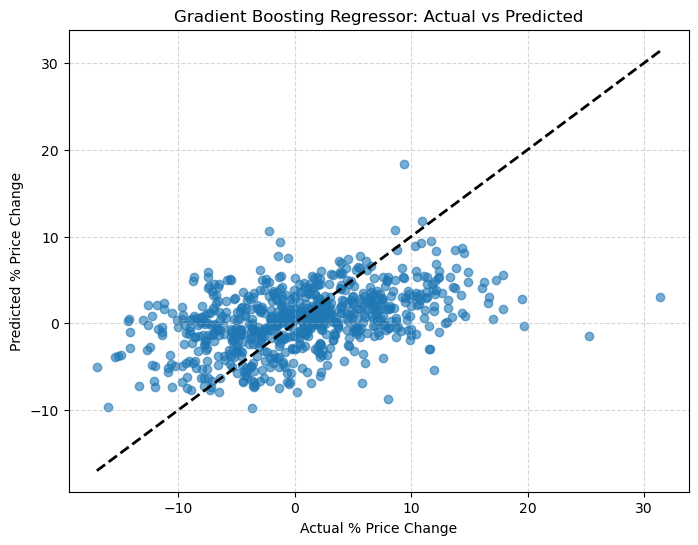

In [45]:
# =====================================================
# GRADIENT BOOSTING REGRESSOR – PREDICT STOCK % PRICE CHANGE
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -------------------------------
# Suppress warnings
# -------------------------------
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------------------
# 1️⃣ Feature set & target
# -------------------------------
features = [
    'ROCE_capped',
    'OPM',
    'ATO',
    'ROA',
    'de_ratio',
    'EPS growth 3Years',
    'PEG Ratio',
    'Market Capitalization',
    'efficiency_score'
]

target = 'price_change_%'

# Drop rows with missing values in selected features/target
df = full_data[features + [target]].dropna().copy()

X = df[features]
y = df[target]

# -------------------------------
# 2️⃣ Train / Test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# -------------------------------
# 3️⃣ Scale features (optional for GBR)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# 4️⃣ GridSearch for GBR hyperparameters
# -------------------------------
param_grid_gbr = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gbr = GradientBoostingRegressor(random_state=42)
grid_search_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=3,
    n_jobs=1,
    verbose=2
)

# Fit GridSearch
grid_search_gbr.fit(X_train_scaled, y_train)

# Best hyperparameters
best_params_gbr = grid_search_gbr.best_params_
print("\n✅ Best GBR parameters:", best_params_gbr)

# -------------------------------
# 5️⃣ Train GBR with best parameters
# -------------------------------
best_gbr = GradientBoostingRegressor(**best_params_gbr, random_state=42)
best_gbr.fit(X_train_scaled, y_train)

# -------------------------------
# 6️⃣ Predictions & Performance
# -------------------------------
y_pred = best_gbr.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 GRADIENT BOOSTING REGRESSOR PERFORMANCE")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# -------------------------------
# 7️⃣ Feature importance
# -------------------------------
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': best_gbr.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📈 FEATURE IMPORTANCE")
print(feat_imp.to_string(index=False))

# -------------------------------
# 8️⃣ Actual vs Predicted plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
plt.xlabel("Actual % Price Change")
plt.ylabel("Predicted % Price Change")
plt.title("Gradient Boosting Regressor: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# results
gbr_results = {
    "Model": "Gradient Boosting",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae
}

gbr_pred = y_pred.copy()


Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.7; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0.7; total time=   0.1s
[CV] END colsampl

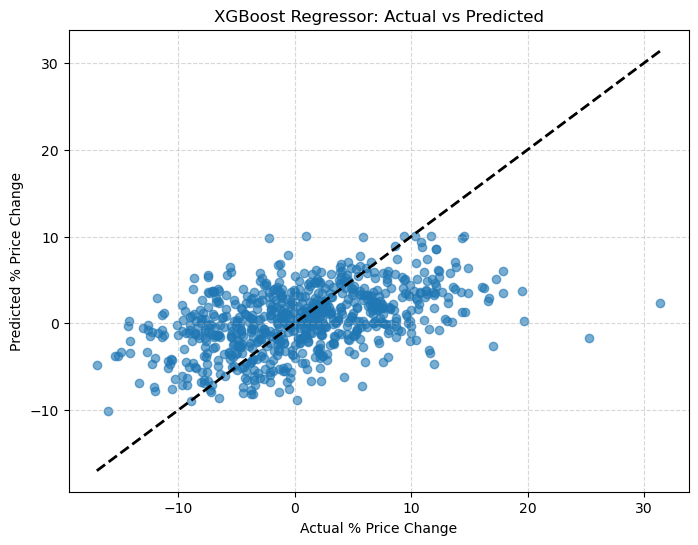

In [46]:
# =====================================================
# XGBOOST REGRESSOR – PREDICT STOCK % PRICE CHANGE
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Import XGBoost
from xgboost import XGBRegressor

# -------------------------------
# Suppress warnings
# -------------------------------
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------------------
# 1️⃣ Feature set & target
# -------------------------------
features = [
    'ROCE_capped',
    'OPM',
    'ATO',
    'ROA',
    'de_ratio',
    'EPS growth 3Years',
    'PEG Ratio',
    'Market Capitalization',
    'efficiency_score'
]

target = 'price_change_%'

# Drop rows with missing values
df = full_data[features + [target]].dropna().copy()

X = df[features]
y = df[target]

# -------------------------------
# 2️⃣ Train / Test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# -------------------------------
# 3️⃣ Scale features (optional for XGBoost)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# 4️⃣ GridSearch for XGB hyperparameters
# -------------------------------
param_grid_xgb = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

xgb = XGBRegressor(random_state=42, n_jobs=1, objective='reg:squarederror')

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    n_jobs=1,
    verbose=2
)

# Fit GridSearch
grid_search_xgb.fit(X_train_scaled, y_train)

# Best hyperparameters
best_params_xgb = grid_search_xgb.best_params_
print("\n✅ Best XGBoost parameters:", best_params_xgb)

# -------------------------------
# 5️⃣ Train XGB with best parameters
# -------------------------------
best_xgb = XGBRegressor(**best_params_xgb, random_state=42, n_jobs=1, objective='reg:squarederror')
best_xgb.fit(X_train_scaled, y_train)

# -------------------------------
# 6️⃣ Predictions & Performance
# -------------------------------
y_pred = best_xgb.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 XGBOOST REGRESSOR PERFORMANCE")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# -------------------------------
# 7️⃣ Feature importance
# -------------------------------
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📈 FEATURE IMPORTANCE")
print(feat_imp.to_string(index=False))

# -------------------------------
# 8️⃣ Actual vs Predicted plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
plt.xlabel("Actual % Price Change")
plt.ylabel("Predicted % Price Change")
plt.title("XGBoost Regressor: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# results
xgb_results = {
    "Model": "XGBoost",
    "R2": r2,
    "RMSE": rmse,
    "MAE": mae
}

xgb_pred = y_pred.copy()



📊 FINAL MODEL PERFORMANCE SUMMARY
               Model        R2      RMSE       MAE
0      Random Forest  0.225435  6.046094  4.803190
2            XGBoost  0.203146  6.132470  4.820604
1  Gradient Boosting  0.184131  6.205205  4.884873
3                MLP  0.131556  6.402016  5.022924
6              Lasso  0.047802  6.703622  5.299400
7        Elastic Net  0.045199  6.712778  5.307659
5              Ridge  0.019943  6.800981  5.365143
4  Linear Regression -0.084998  7.155835  5.456146


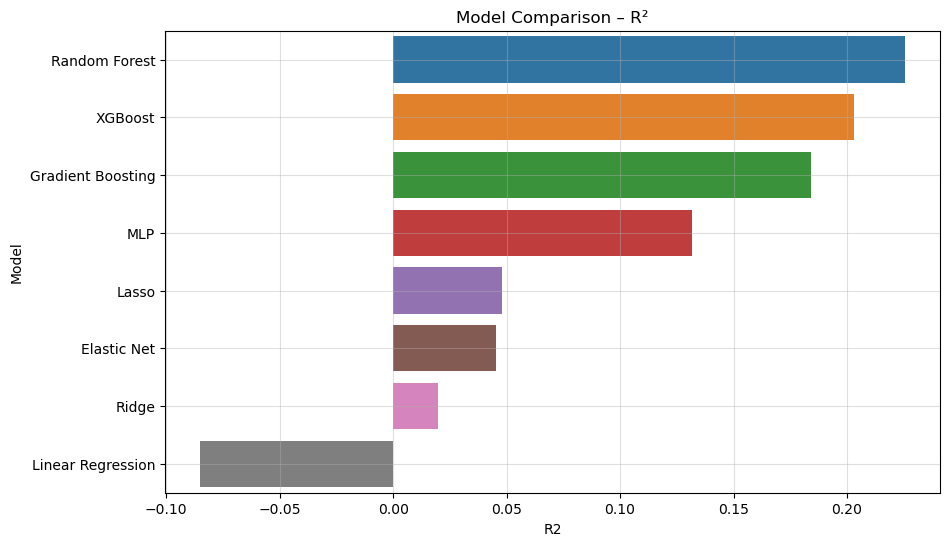

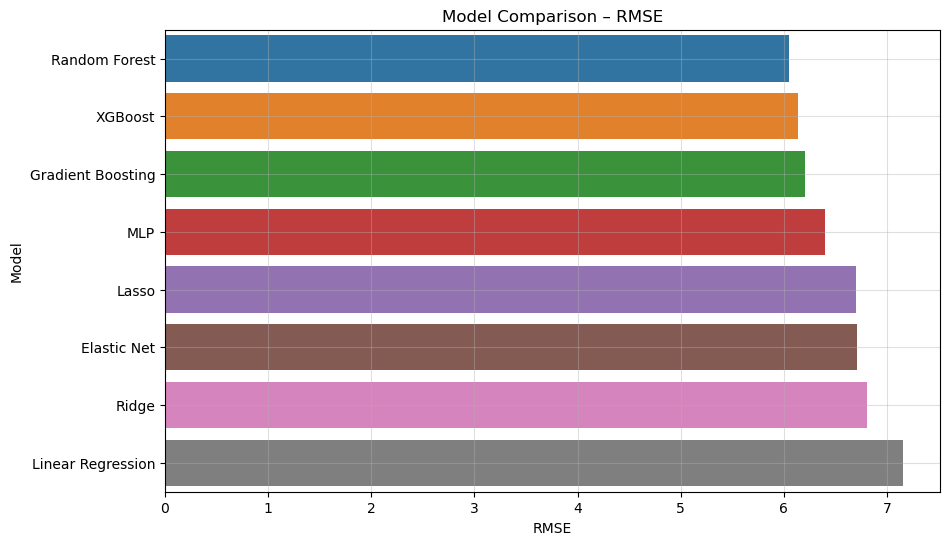

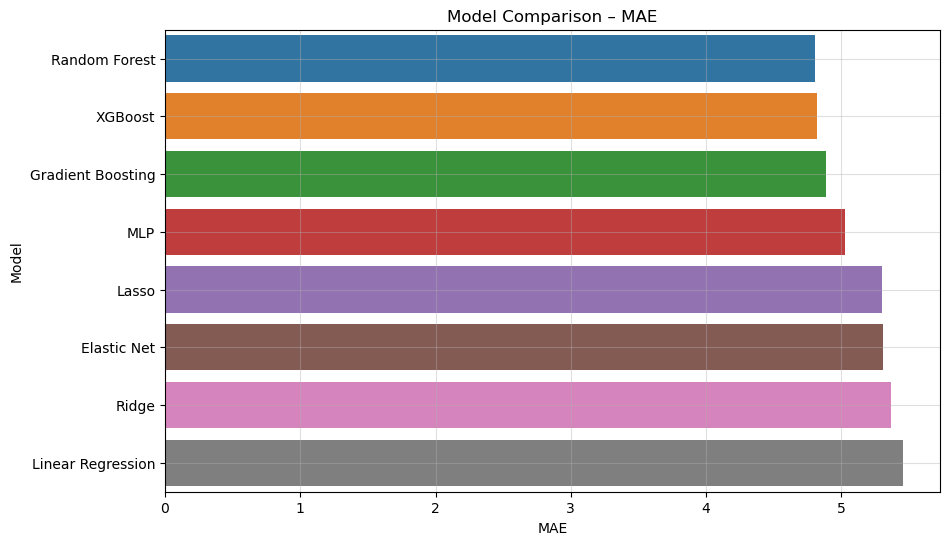


📈 FEATURE IMPORTANCE / COEFFICIENTS SUMMARY

--- Random Forest ---
              Feature  Importance
Market Capitalization    0.315646
          ROCE_capped    0.255033
             de_ratio    0.133184
                  ROA    0.119093
            PEG Ratio    0.060896
                  OPM    0.036149
                  ATO    0.027156
    EPS growth 3Years    0.026771
     efficiency_score    0.026071

--- Gradient Boosting ---
              Feature  Importance
Market Capitalization    0.258964
          ROCE_capped    0.209279
                  ROA    0.155517
             de_ratio    0.129014
            PEG Ratio    0.089862
    EPS growth 3Years    0.047643
     efficiency_score    0.042059
                  ATO    0.039642
                  OPM    0.028020

--- XGBoost ---
              Feature  Importance
Market Capitalization    0.195806
          ROCE_capped    0.180815
                  ROA    0.131664
             de_ratio    0.118807
            PEG Ratio    0.091621
    

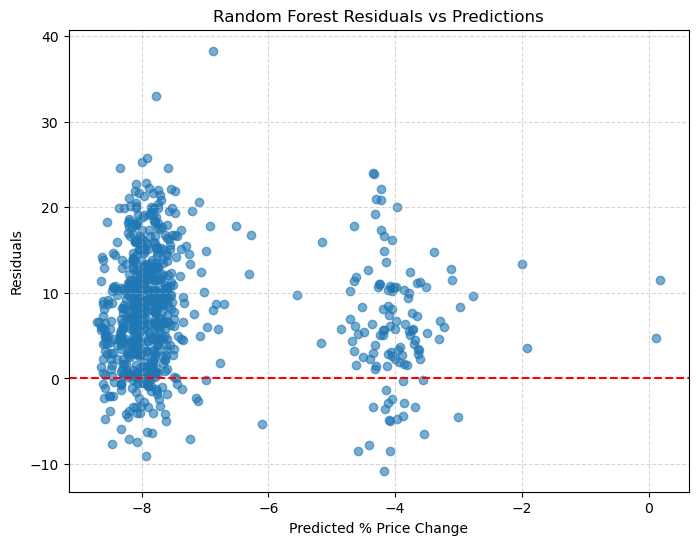

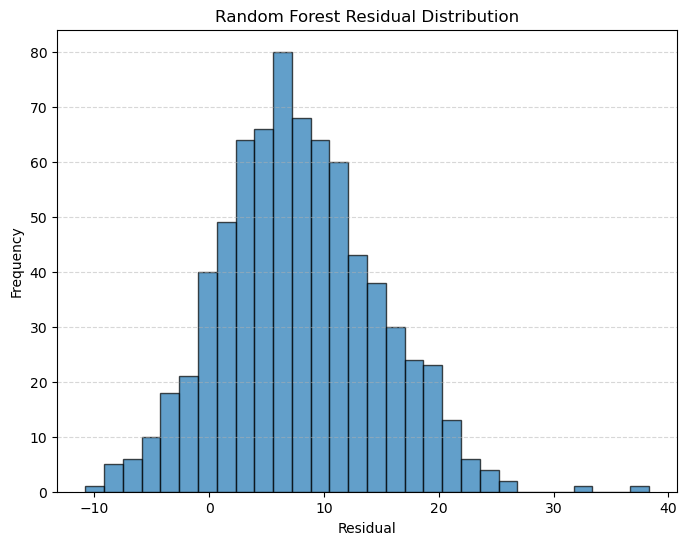

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


results = [
    rf_results,        # Random Forest
    gbr_results,       # Gradient Boosting
    xgb_results,       # XGBoost
    mlp_results,       # MLP
    lr_results,        # Linear Regression
    ridge_results,     # Ridge
    lasso_results,     # Lasso
    enet_results       # Elastic Net
]

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)

print("\n📊 FINAL MODEL PERFORMANCE SUMMARY")
print(results_df)

plt.figure(figsize=(10,6))
sns.barplot(x="R2", y="Model", data=results_df)
plt.title("Model Comparison – R²")
plt.grid(True, alpha=0.4)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x="RMSE", y="Model", data=results_df)
plt.title("Model Comparison – RMSE")
plt.grid(True, alpha=0.4)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x="MAE", y="Model", data=results_df)
plt.title("Model Comparison – MAE")
plt.grid(True, alpha=0.4)
plt.show()


print("\n📈 FEATURE IMPORTANCE / COEFFICIENTS SUMMARY")

model_objects = {
    "Random Forest": best_rf,
    "Gradient Boosting": best_gbr,
    "XGBoost": best_xgb,
    "Linear Regression": linreg,
    "Ridge": ridge_pipeline.named_steps["ridge"],
    "Lasso": lasso_pipeline.named_steps["lasso"],
    "ElasticNet": elastic_net
}

for name, model in model_objects.items():
    print(f"\n--- {name} ---")

    if hasattr(model, "feature_importances_"):
        df_imp = pd.DataFrame({
            "Feature": features,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)
        print(df_imp.to_string(index=False))

    elif hasattr(model, "coef_"):
        df_coef = pd.DataFrame({
            "Feature": features,
            "Coefficient": model.coef_
        }).sort_values("Coefficient", key=abs, ascending=False)
        print(df_coef.to_string(index=False))

    else:
        print("No direct interpretability (e.g. MLP)")


best_model_name = "Random Forest"
best_model = best_rf
print(f"\n✅ Best Model: {best_model_name}")

# 🔑 DEFINE THESE EXPLICITLY
best_model_predictions = best_model.predict(X_test)
residuals = y_test - best_model_predictions

# -------------------------------
# Residuals vs Predictions
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(best_model_predictions, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted % Price Change")
plt.ylabel("Residuals")
plt.title("Random Forest Residuals vs Predictions")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# -------------------------------
# Residual distribution
# -------------------------------
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Random Forest Residual Distribution")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


                  Name  predicted_price_change_%
2821  Ventura Textiles                  9.314866
2104  Rajkot Inv.Trust                  8.773343
839     Flora Textiles                  8.685799
1833         OTCO Intl                  8.671017
1341       K Z Leasing                  7.710819
148   Alstone Textiles                  7.677092
2050      Quasar India                  7.587035
134   Alfavision Overs                  7.453611
2556  Suryavanshi Spg.                  7.379926
1177       IndiaNivesh                  7.371631


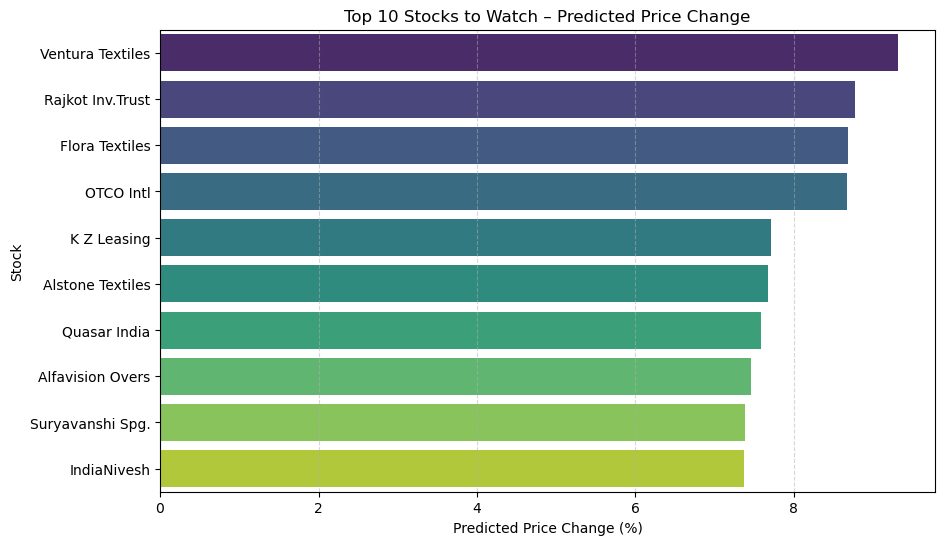

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# -------------------------------
# 1️⃣ Features & target
# -------------------------------
features = [
    'ROCE_capped', 'OPM', 'ATO', 'ROA', 'de_ratio', 
    'EPS growth 3Years', 'PEG Ratio', 'Market Capitalization', 'efficiency_score'
]
target = 'price_change_%'

# Drop rows with missing values in features/target
df_full = full_data[features + [target, 'Name', 'Last result date']].dropna().copy()

X_full = df_full[features]
y_full = df_full[target]

# -------------------------------
# 2️⃣ Scale features
# -------------------------------
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

# -------------------------------
# 3️⃣ Retrain Random Forest on full data
# -------------------------------
# Use best parameters from previous tuning
best_rf_params = {k: v for k,v in best_rf.get_params().items() if k != 'random_state'}
rf_final = RandomForestRegressor(**best_rf_params, random_state=42)
rf_final.fit(X_full_scaled, y_full)

# -------------------------------
# 4️⃣ Latest snapshot per stock
# -------------------------------
latest_data = df_full.sort_values(['Name', 'Last result date']).groupby('Name').last().reset_index()
X_latest = latest_data[features]
X_latest_scaled = scaler.transform(X_latest)

# -------------------------------
# 5️⃣ Predict % price change
# -------------------------------
latest_data['predicted_price_change_%'] = rf_final.predict(X_latest_scaled)

# -------------------------------
# 6️⃣ Top 10 stocks to watch
# -------------------------------
top_10 = latest_data.sort_values('predicted_price_change_%', ascending=False).head(10)
print(top_10[['Name', 'predicted_price_change_%']])


import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Horizontal bar chart – Top 10 predicted stocks
# -------------------------------
plt.figure(figsize=(10,6))
sns.barplot(
    x='predicted_price_change_%', 
    y='Name', 
    data=top_10,
    palette='viridis'
)
plt.xlabel("Predicted Price Change (%)")
plt.ylabel("Stock")
plt.title("Top 10 Stocks to Watch – Predicted Price Change")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()
